# QuickBite Food Delivery – Applied Business Analytics Project
Step-by-step notebook based on `quickbite_food_delivery_business_analytics.csv`.

Run the cells from top to bottom. The notebook follows the analytical requirements in the supplied ABA project format.


In [3]:
# STEP 1: Install packages (run once in Jupyter/Colab if needed)
# !pip install pandas numpy matplotlib seaborn scipy statsmodels scikit-learn


In [4]:
# STEP 2: Import libraries
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.optimize import linprog
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.formula.api import ols
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

OUT_DIR = "quickbite_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 6)


In [5]:
# STEP 3: Load the exact CSV dataset
DATA_FILE = "quickbite_food_delivery_business_analytics.csv"

df = pd.read_csv(DATA_FILE)
df["Order_Date"] = pd.to_datetime(df["Order_Date"], errors="coerce")

print("Dataset loaded successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Dataset loaded successfully
Rows: 10000
Columns: 24


In [6]:
# STEP 4: First five records
df.head(5)


,Order_ID,Order_Date,Customer_ID,Age,Gender,City,Restaurant_Category,Cuisine,Order_Value,Items_Count,...,Payment_Method,Order_Status,Marketing_Channel,Marketing_Spend,Landing_Page_Version,Conversion_Status,Delivery_Partner,Peak_Hour,Profit,Returned_Refund
0,QB00001,2025-04-25,CUST2419,32,Male,Hyderabad,Casual Dining,Biryani,850.45,3,...,Wallet,Completed,Social Media,450.69,A - Buy Now,Converted,Partner A,Off-Peak,320.54,0
1,QB00002,2026-03-09,CUST0903,21,Male,Mumbai,Casual Dining,Biryani,907.45,3,...,Card,Completed,Email,521.54,A - Buy Now,Converted,Partner D,Off-Peak,303.14,0
2,QB00003,2026-04-05,CUST0419,28,Other,Pune,Quick Service,Chinese,446.76,1,...,UPI,Completed,Online Ads,594.76,B - Get Started,Converted,Partner C,Peak,116.07,0
3,QB00004,2025-04-05,CUST0323,28,Female,Mumbai,Cafe,Pizza,549.00,2,...,Wallet,Completed,Online Ads,569.33,B - Get Started,Converted,Partner D,Off-Peak,137.14,0
4,QB00005,2026-07-20,CUST0327,27,Female,Delhi,Cloud Kitchen,Burger,603.55,2,...,UPI,Completed,Online Ads,454.10,A - Buy Now,Converted,Partner C,Peak,162.41,0


In [7]:
# STEP 5: Last five records
df.tail(5)


,Order_ID,Order_Date,Customer_ID,Age,Gender,City,Restaurant_Category,Cuisine,Order_Value,Items_Count,...,Payment_Method,Order_Status,Marketing_Channel,Marketing_Spend,Landing_Page_Version,Conversion_Status,Delivery_Partner,Peak_Hour,Profit,Returned_Refund
9995,QB09996,2025-08-18,CUST0678,29,Other,Mumbai,Cloud Kitchen,North Indian,494.08,2,...,UPI,Completed,Online Ads,779.48,A - Buy Now,Converted,Partner C,Off-Peak,106.76,0
9996,QB09997,2026-06-01,CUST2688,28,Female,Hyderabad,Cafe,Pizza,0.00,3,...,Card,Failed,Social Media,449.97,B - Get Started,Not Converted,Partner D,Off-Peak,-53.33,0
9997,QB09998,2025-04-02,CUST1432,31,Female,Mumbai,Cloud Kitchen,Burger,522.14,1,...,UPI,Completed,Email,209.71,A - Buy Now,Converted,Partner D,Peak,155.23,0
9998,QB09999,2025-04-05,CUST0982,27,Male,Pune,Bakery,Pizza,406.06,2,...,Card,Completed,Social Media,505.35,B - Get Started,Converted,Partner A,Peak,84.31,0
9999,QB10000,2025-03-04,CUST2994,31,Male,Delhi,Cafe,Chinese,429.98,2,...,UPI,Completed,Online Ads,609.34,A - Buy Now,Converted,Partner A,Off-Peak,64.53,0


In [8]:
# STEP 6: Dataset shape
print("Shape:", df.shape)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])


Shape: (10000, 24)
Rows: 10000
Columns: 24


In [9]:
# STEP 7: Column names
for i, col in enumerate(df.columns, start=1):
    print(i, col)


1 Order_ID
2 Order_Date
3 Customer_ID
4 Age
5 Gender
6 City
7 Restaurant_Category
8 Cuisine
9 Order_Value
10 Items_Count
11 Discount_Percent
12 Delivery_Distance_km
13 Delivery_Time_min
14 Customer_Rating
15 Payment_Method
16 Order_Status
17 Marketing_Channel
18 Marketing_Spend
19 Landing_Page_Version
20 Conversion_Status
21 Delivery_Partner
22 Peak_Hour
23 Profit
24 Returned_Refund


In [10]:
# STEP 8: Data types
print(df.dtypes)


Order_ID                           str
Order_Date              datetime64[us]
Customer_ID                        str
Age                              int64
Gender                             str
City                               str
Restaurant_Category                str
Cuisine                            str
Order_Value                    float64
Items_Count                      int64
Discount_Percent               float64
Delivery_Distance_km           float64
Delivery_Time_min              float64
Customer_Rating                float64
Payment_Method                     str
Order_Status                       str
Marketing_Channel                  str
Marketing_Spend                float64
Landing_Page_Version               str
Conversion_Status                  str
Delivery_Partner                   str
Peak_Hour                          str
Profit                         float64
Returned_Refund                  int64
dtype: object


In [11]:
# STEP 9: Dataset information
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order_ID              10000 non-null  str           
 1   Order_Date            10000 non-null  datetime64[us]
 2   Customer_ID           10000 non-null  str           
 3   Age                   10000 non-null  int64         
 4   Gender                10000 non-null  str           
 5   City                  10000 non-null  str           
 6   Restaurant_Category   10000 non-null  str           
 7   Cuisine               10000 non-null  str           
 8   Order_Value           10000 non-null  float64       
 9   Items_Count           10000 non-null  int64         
 10  Discount_Percent      10000 non-null  float64       
 11  Delivery_Distance_km  10000 non-null  float64       
 12  Delivery_Time_min     10000 non-null  float64       
 13  Customer_Rating       10000 

In [12]:
# STEP 10: Missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing %": missing_percent
})

print(missing_table)


                      Missing Values  Missing %
Order_ID                           0        0.0
Order_Date                         0        0.0
Customer_ID                        0        0.0
Age                                0        0.0
Gender                             0        0.0
City                               0        0.0
Restaurant_Category                0        0.0
Cuisine                            0        0.0
Order_Value                        0        0.0
Items_Count                        0        0.0
Discount_Percent                   0        0.0
Delivery_Distance_km               0        0.0
Delivery_Time_min                  0        0.0
Customer_Rating                    0        0.0
Payment_Method                     0        0.0
Order_Status                       0        0.0
Marketing_Channel                  0        0.0
Marketing_Spend                    0        0.0
Landing_Page_Version               0        0.0
Conversion_Status                  0    

In [13]:
# STEP 11: Duplicate records
duplicate_count = df.duplicated().sum()
print("Duplicate records:", duplicate_count)


Duplicate records: 0


In [14]:
# STEP 12: Unique values
categorical_columns = [
    "Gender", "City", "Restaurant_Category", "Cuisine",
    "Payment_Method", "Order_Status", "Marketing_Channel",
    "Landing_Page_Version", "Conversion_Status",
    "Delivery_Partner", "Peak_Hour"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].unique())



Gender
<ArrowStringArray>
['Male', 'Other', 'Female']
Length: 3, dtype: str

City
<ArrowStringArray>
['Hyderabad',    'Mumbai',      'Pune',     'Delhi',     'Thane',    'Nashik',
    'Jaipur', 'Bengaluru', 'Ahmedabad',    'Nagpur']
Length: 10, dtype: str

Restaurant_Category
<ArrowStringArray>
['Casual Dining', 'Quick Service', 'Cafe', 'Cloud Kitchen', 'Bakery']
Length: 5, dtype: str

Cuisine
<ArrowStringArray>
[     'Biryani',      'Chinese',        'Pizza',       'Burger',
      'Healthy', 'South Indian', 'North Indian',     'Desserts']
Length: 8, dtype: str

Payment_Method
<ArrowStringArray>
['Wallet', 'Card', 'UPI', 'Cash']
Length: 4, dtype: str

Order_Status
<ArrowStringArray>
['Completed', 'Cancelled', 'Failed']
Length: 3, dtype: str

Marketing_Channel
<ArrowStringArray>
['Social Media', 'Email', 'Online Ads', 'Referral']
Length: 4, dtype: str

Landing_Page_Version
<ArrowStringArray>
['A - Buy Now', 'B - Get Started']
Length: 2, dtype: str

Conversion_Status
<ArrowStringArray>


In [15]:
# STEP 13: Number of unique values in each column
print(df.nunique())


Order_ID                10000
Order_Date                608
Customer_ID              3056
Age                        40
Gender                      3
City                       10
Restaurant_Category         5
Cuisine                     8
Order_Value              6437
Items_Count                 7
Discount_Percent         2470
Delivery_Distance_km     1242
Delivery_Time_min        3444
Customer_Rating            23
Payment_Method              4
Order_Status                3
Marketing_Channel           4
Marketing_Spend          9111
Landing_Page_Version        2
Conversion_Status           2
Delivery_Partner            4
Peak_Hour                   2
Profit                   8257
Returned_Refund             2
dtype: int64


In [16]:
# STEP 14: Data preprocessing – remove duplicate rows if any
df_clean = df.drop_duplicates().copy()

print("Before:", len(df))
print("After :", len(df_clean))


Before: 10000
After : 10000


In [17]:
# STEP 15: Data validation / invalid values
checks = {
    "Age outside 18-100":
        ((df_clean["Age"] < 18) | (df_clean["Age"] > 100)).sum(),

    "Items_Count <= 0":
        (df_clean["Items_Count"] <= 0).sum(),

    "Order_Value < 0":
        (df_clean["Order_Value"] < 0).sum(),

    "Discount outside 0-100":
        ((df_clean["Discount_Percent"] < 0) |
         (df_clean["Discount_Percent"] > 100)).sum(),

    "Delivery distance <= 0":
        (df_clean["Delivery_Distance_km"] <= 0).sum(),

    "Delivery time <= 0":
        (df_clean["Delivery_Time_min"] <= 0).sum(),

    "Rating outside 1-5":
        ((df_clean["Customer_Rating"] < 1) |
         (df_clean["Customer_Rating"] > 5)).sum()
}

for key, value in checks.items():
    print(f"{key}: {value}")


Age outside 18-100: 0
Items_Count <= 0: 0
Order_Value < 0: 0
Discount outside 0-100: 0
Delivery distance <= 0: 0
Delivery time <= 0: 0
Rating outside 1-5: 0


In [18]:
# STEP 16: Outlier check using IQR for Order_Value
Q1 = df_clean["Order_Value"].quantile(0.25)
Q3 = df_clean["Order_Value"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

order_value_outliers = df_clean[
    (df_clean["Order_Value"] < lower_bound) |
    (df_clean["Order_Value"] > upper_bound)
]

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))
print("Number of outliers:", len(order_value_outliers))


Q1: 0.0
Q3: 506.12
IQR: 506.12
Lower bound: -759.18
Upper bound: 1265.3
Number of outliers: 0


In [19]:
# STEP 17: Save the cleaned dataset
clean_file = os.path.join(OUT_DIR, "quickbite_cleaned_data.csv")
df_clean.to_csv(clean_file, index=False)
print("Saved:", clean_file)


Saved: quickbite_outputs\quickbite_cleaned_data.csv


In [20]:
# STEP 18: EDA – basic statistical summary
print(df_clean.describe().round(2))


                       Order_Date       Age  Order_Value  Items_Count  \
count                       10000  10000.00     10000.00     10000.00   
mean   2025-11-01 01:37:37.920000     28.86       328.20         3.20   
min           2025-01-01 00:00:00     18.00         0.00         1.00   
25%           2025-06-03 00:00:00     23.00         0.00         2.00   
50%           2025-11-01 00:00:00     28.00       363.20         3.00   
75%           2026-04-02 00:00:00     34.00       506.12         4.00   
max           2026-08-31 00:00:00     57.00      1259.53         7.00   
std                           NaN      7.40       263.87         1.46   

       Discount_Percent  Delivery_Distance_km  Delivery_Time_min  \
count          10000.00              10000.00           10000.00   
mean              14.05                  4.57              31.65   
min                0.00                  0.50              12.00   
25%                9.87                  2.33              25.00   
50

Restaurant_Category
Casual Dining    978760.52
Cloud Kitchen    715322.32
Cafe             582648.29
Quick Service    527496.39
Bakery           477813.35
Name: Order_Value, dtype: float64


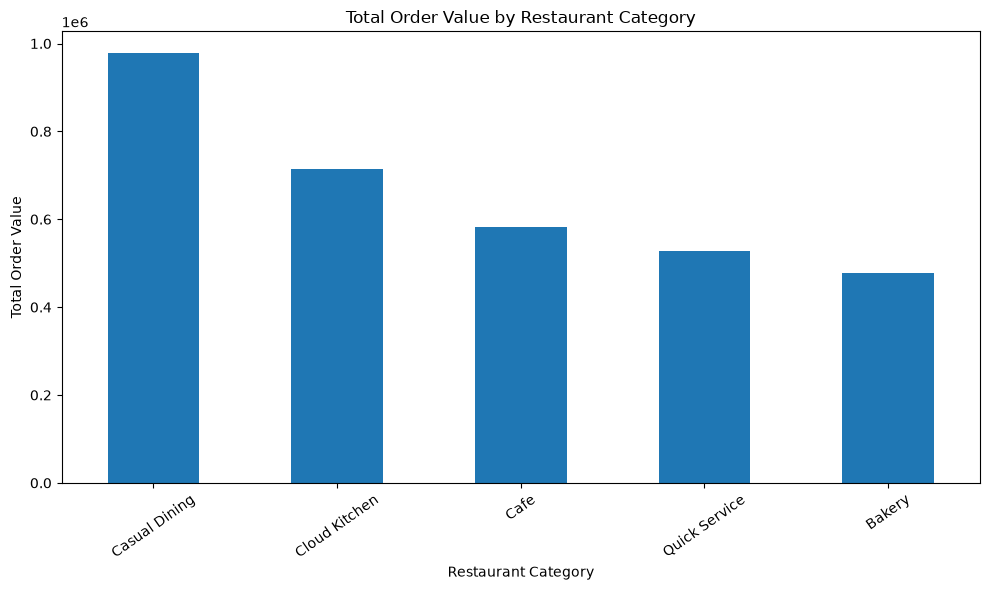

In [21]:
# STEP 19: EDA – Bar Chart 1
category_sales = (
    df_clean.groupby("Restaurant_Category")["Order_Value"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales.round(2))

plt.figure(figsize=(10, 6))
category_sales.plot(kind="bar")
plt.title("Total Order Value by Restaurant Category")
plt.xlabel("Restaurant Category")
plt.ylabel("Total Order Value")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "01_bar_order_value_by_category.png"), dpi=200)
plt.show()
plt.close()


Marketing_Channel
Social Media    231401.62
Online Ads      222819.01
Email           128630.73
Referral        127796.40
Name: Profit, dtype: float64


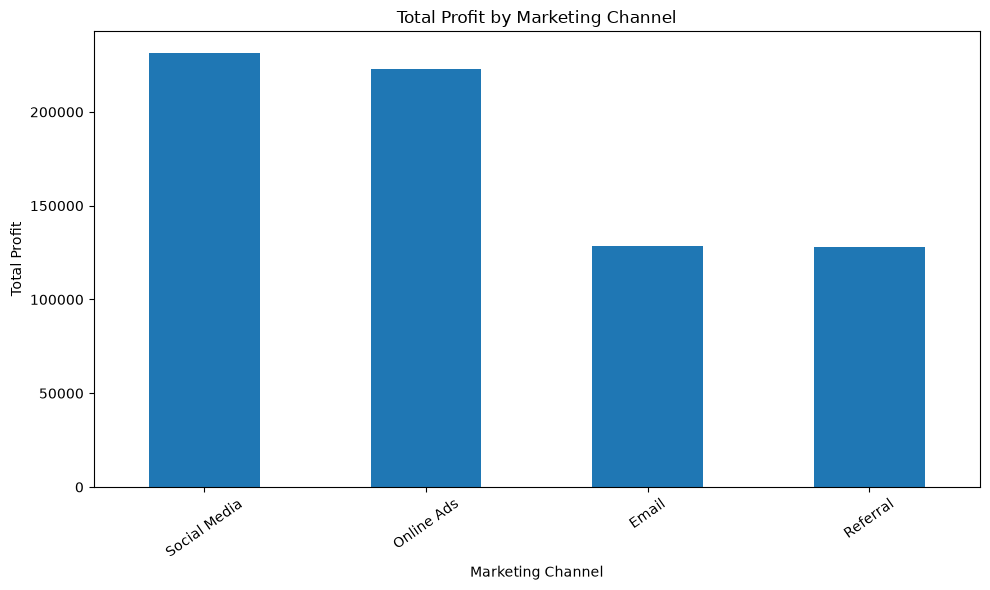

In [22]:
# STEP 20: EDA – Bar Chart 2
channel_profit = (
    df_clean.groupby("Marketing_Channel")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print(channel_profit.round(2))

plt.figure(figsize=(10, 6))
channel_profit.plot(kind="bar")
plt.title("Total Profit by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Total Profit")
plt.xticks(rotation=35)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "02_bar_profit_by_channel.png"), dpi=200)
plt.show()
plt.close()


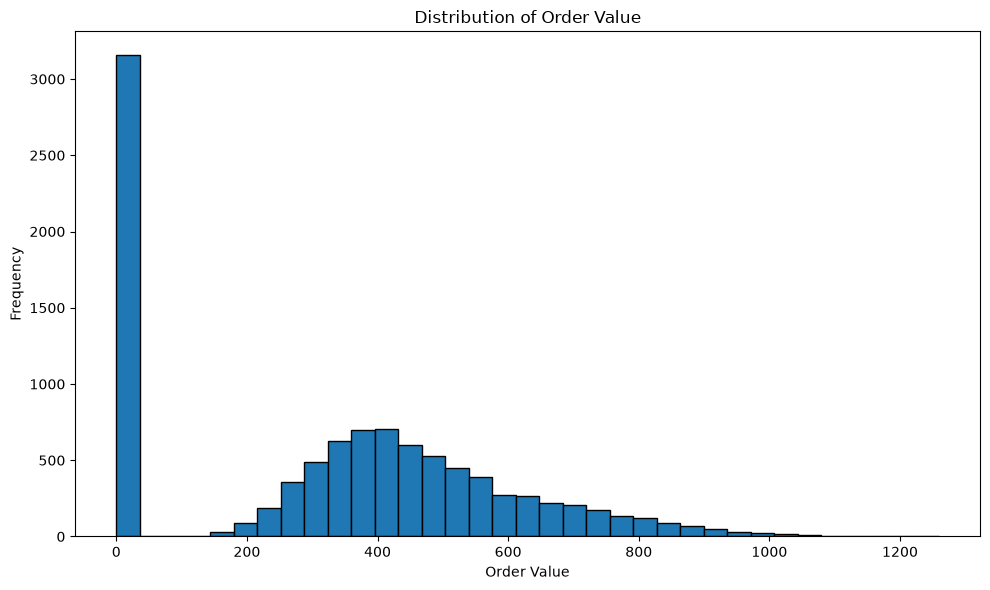

In [23]:
# STEP 21: EDA – Histogram 1
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Order_Value"], bins=35, edgecolor="black")
plt.title("Distribution of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "03_histogram_order_value.png"), dpi=200)
plt.show()
plt.close()


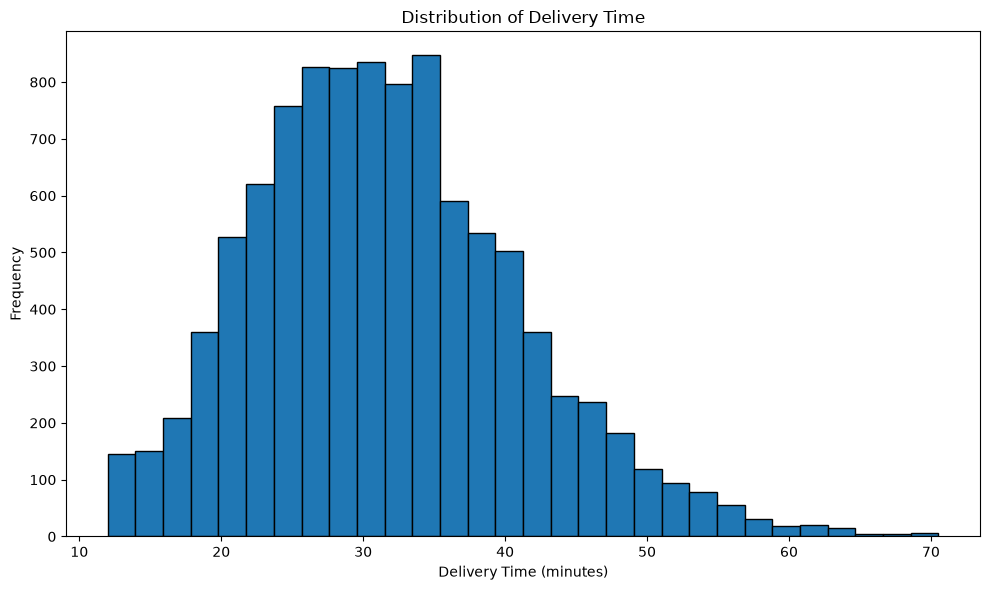

In [24]:
# STEP 22: EDA – Histogram 2
plt.figure(figsize=(10, 6))
plt.hist(df_clean["Delivery_Time_min"], bins=30, edgecolor="black")
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "04_histogram_delivery_time.png"), dpi=200)
plt.show()
plt.close()


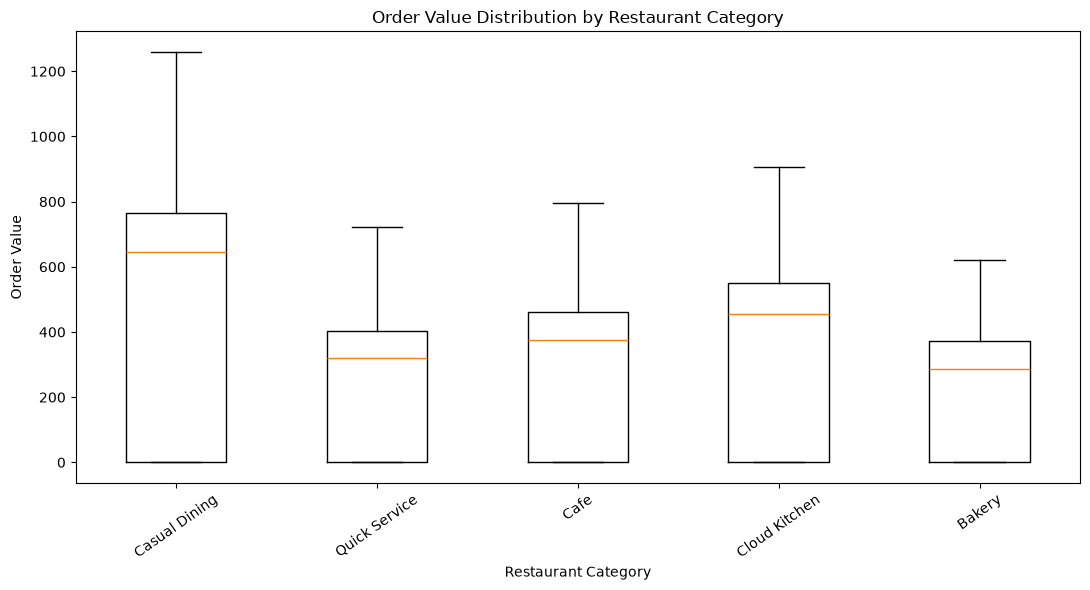

In [27]:
# STEP 23: EDA - Box Plot

categories = df_clean["Restaurant_Category"].unique()

box_data = [
    df_clean.loc[
        df_clean["Restaurant_Category"] == category,
        "Order_Value"
    ]
    for category in categories
]

plt.figure(figsize=(11, 6))

plt.boxplot(
    box_data,
    tick_labels=categories
)

plt.title("Order Value Distribution by Restaurant Category")
plt.xlabel("Restaurant Category")
plt.ylabel("Order Value")

plt.xticks(rotation=35)

plt.tight_layout()

plt.savefig(
    os.path.join(
        OUT_DIR,
        "05_boxplot_order_value_category.png"
    ),
    dpi=200
)

plt.show()
plt.close()

Payment_Method
UPI       4572
Card      2771
Wallet    1490
Cash      1167
Name: count, dtype: int64


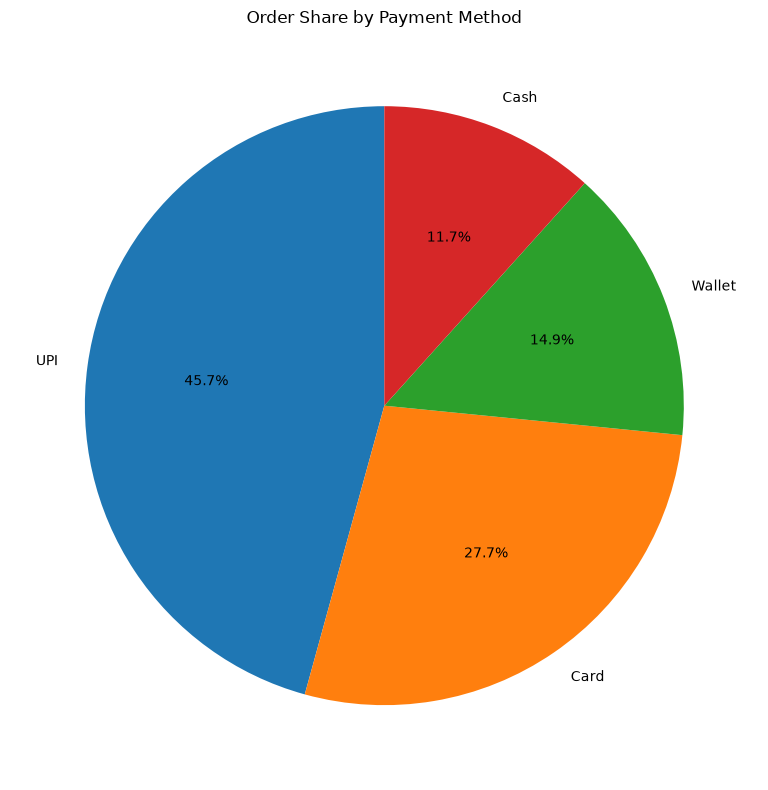

In [26]:
# STEP 24: EDA – Pie Chart
payment_counts = df_clean["Payment_Method"].value_counts()

print(payment_counts)

plt.figure(figsize=(8, 8))
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Order Share by Payment Method")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "06_pie_payment_method.png"), dpi=200)
plt.show()
plt.close()


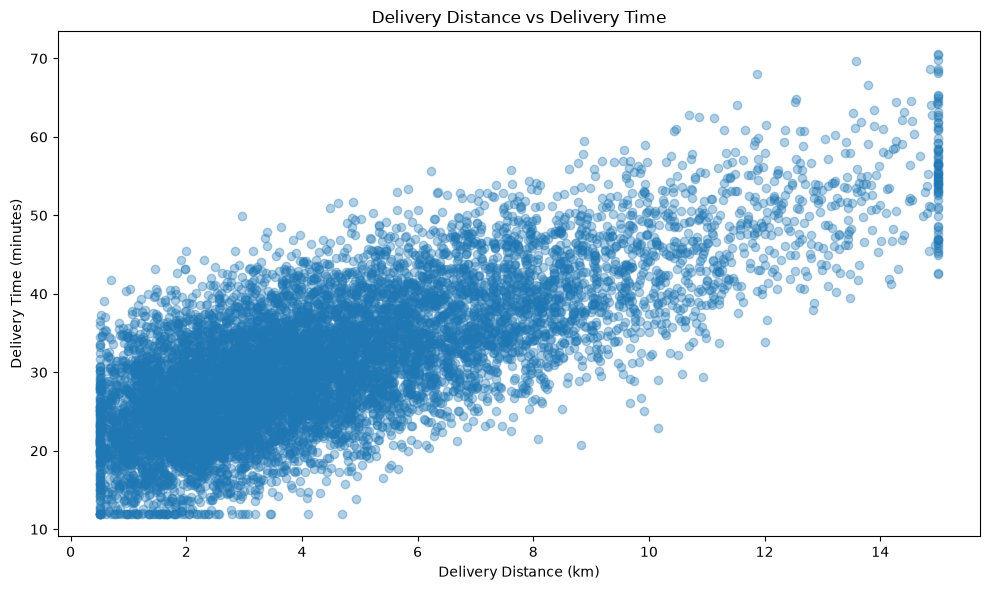

In [28]:
# STEP 25: EDA – Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df_clean["Delivery_Distance_km"],
    df_clean["Delivery_Time_min"],
    alpha=0.35
)
plt.title("Delivery Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "07_scatter_distance_vs_time.png"), dpi=200)
plt.show()
plt.close()


City
Mumbai       776495.50
Pune         441504.36
Bengaluru    357708.73
Thane        337158.11
Delhi        290817.47
Hyderabad    261786.68
Nashik       238152.39
Nagpur       235687.40
Ahmedabad    178629.12
Jaipur       164101.11
Name: Order_Value, dtype: float64


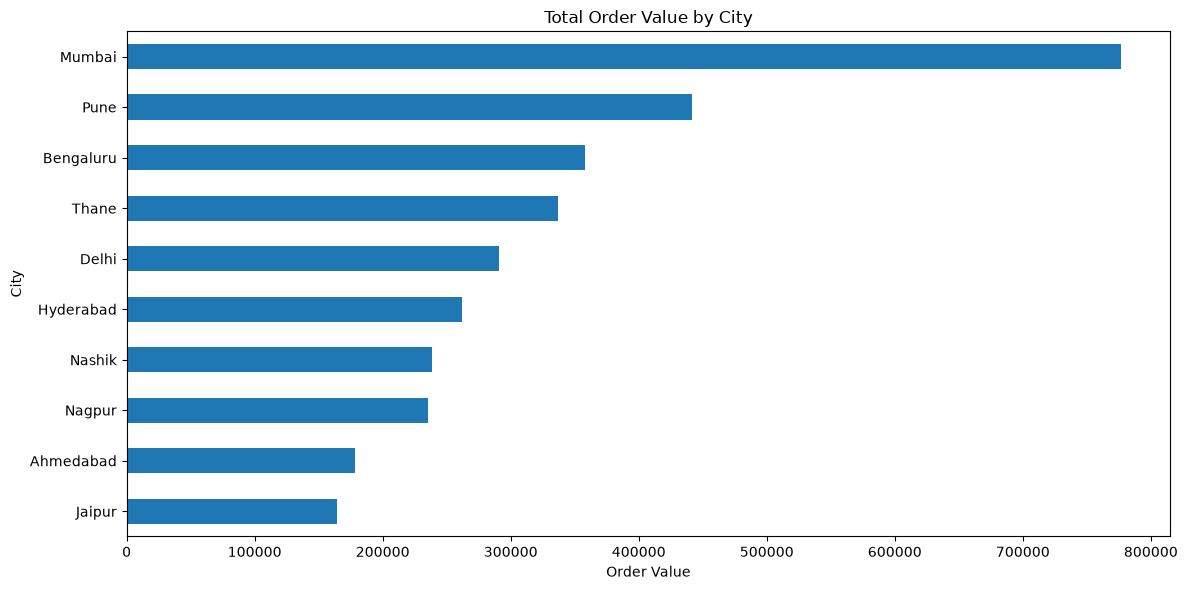

In [29]:
# STEP 26: Extra EDA – Sales by City
city_sales = (
    df_clean.groupby("City")["Order_Value"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales.round(2))

plt.figure(figsize=(12, 6))
city_sales.sort_values().plot(kind="barh")
plt.title("Total Order Value by City")
plt.xlabel("Order Value")
plt.ylabel("City")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "08_sales_by_city.png"), dpi=200)
plt.show()
plt.close()


In [30]:
# STEP 27: Descriptive Statistical Analysis
numeric_columns = [
    "Age", "Order_Value", "Items_Count", "Discount_Percent",
    "Delivery_Distance_km", "Delivery_Time_min",
    "Customer_Rating", "Marketing_Spend", "Profit"
]

descriptive_stats = pd.DataFrame({
    "Mean": df_clean[numeric_columns].mean(),
    "Median": df_clean[numeric_columns].median(),
    "Mode": df_clean[numeric_columns].mode().iloc[0],
    "Minimum": df_clean[numeric_columns].min(),
    "Maximum": df_clean[numeric_columns].max(),
    "Range": df_clean[numeric_columns].max() - df_clean[numeric_columns].min(),
    "Variance": df_clean[numeric_columns].var(),
    "Standard Deviation": df_clean[numeric_columns].std()
})

print(descriptive_stats.round(2))
descriptive_stats.to_csv(
    os.path.join(OUT_DIR, "01_descriptive_statistics.csv")
)


                        Mean  Median   Mode  Minimum  Maximum    Range  \
Age                    28.86   28.00  18.00    18.00    57.00    39.00   
Order_Value           328.20  363.20   0.00     0.00  1259.53  1259.53   
Items_Count             3.20    3.00   3.00     1.00     7.00     6.00   
Discount_Percent       14.05   14.12   0.00     0.00    30.00    30.00   
Delivery_Distance_km    4.57    3.90   0.50     0.50    15.00    14.50   
Delivery_Time_min      31.65   30.90  12.00    12.00    70.53    58.53   
Customer_Rating         4.64    4.70   5.00     2.80     5.00     2.20   
Marketing_Spend       414.64  415.64  50.00    50.00  1008.20   958.20   
Profit                 71.06   83.01 -57.65  -107.79   489.94   597.73   

                      Variance  Standard Deviation  
Age                      54.82                7.40  
Order_Value           69629.86              263.87  
Items_Count               2.13                1.46  
Discount_Percent         35.71                5

Mean: 328.2
Median: 363.2
Standard Deviation: 263.87
Skewness: 0.169
Outliers: 0


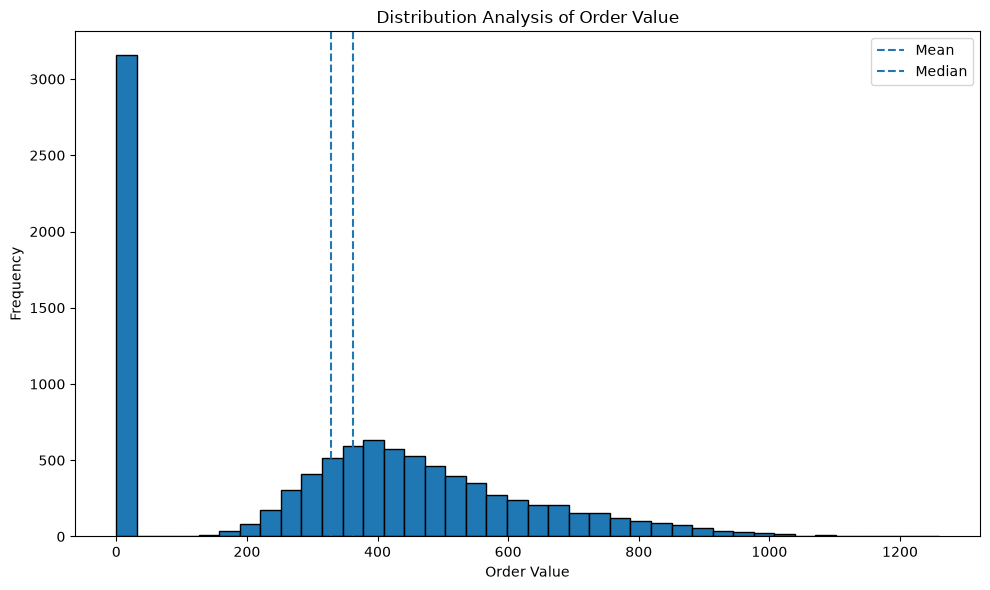

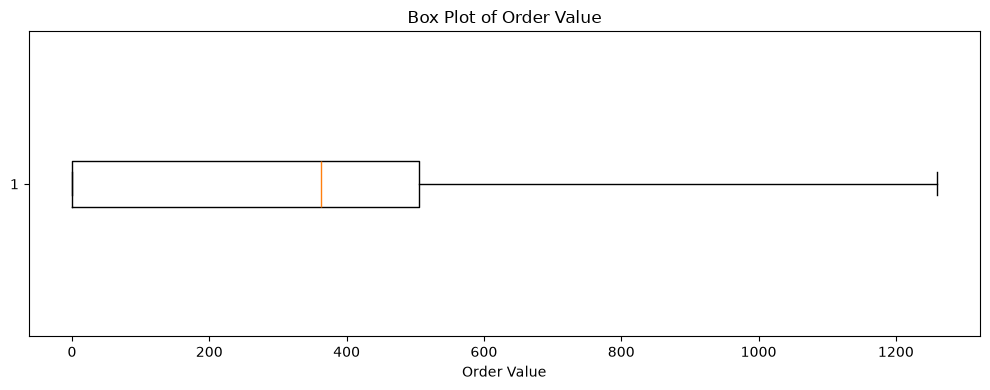

In [31]:
# STEP 28: Distribution Analysis
sales = df_clean["Order_Value"].dropna()

print("Mean:", round(sales.mean(), 2))
print("Median:", round(sales.median(), 2))
print("Standard Deviation:", round(sales.std(), 2))
print("Skewness:", round(sales.skew(), 4))
print("Outliers:", len(order_value_outliers))

plt.figure(figsize=(10, 6))
plt.hist(sales, bins=40, edgecolor="black")
plt.axvline(sales.mean(), linestyle="--", label="Mean")
plt.axvline(sales.median(), linestyle="--", label="Median")
plt.title("Distribution Analysis of Order Value")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "09_distribution_order_value_histogram.png"), dpi=200)
plt.show()
plt.close()

plt.figure(figsize=(10, 4))
plt.boxplot(sales, vert=False)
plt.title("Box Plot of Order Value")
plt.xlabel("Order Value")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "10_distribution_order_value_boxplot.png"), dpi=200)
plt.show()
plt.close()


In [32]:
# STEP 29: Correlation Matrix
correlation_columns = [
    "Order_Value", "Items_Count", "Discount_Percent",
    "Delivery_Distance_km", "Delivery_Time_min",
    "Customer_Rating", "Marketing_Spend", "Profit"
]

corr_matrix = df_clean[correlation_columns].corr()

print(corr_matrix.round(3))
corr_matrix.to_csv(
    os.path.join(OUT_DIR, "02_correlation_matrix.csv")
)


                      Order_Value  Items_Count  Discount_Percent  \
Order_Value                 1.000        0.113            -0.079   
Items_Count                 0.113        1.000             0.016   
Discount_Percent           -0.079        0.016             1.000   
Delivery_Distance_km       -0.003       -0.021             0.002   
Delivery_Time_min           0.012       -0.020            -0.004   
Customer_Rating             0.007        0.021            -0.082   
Marketing_Spend             0.088       -0.017            -0.012   
Profit                      0.977        0.114            -0.079   

                      Delivery_Distance_km  Delivery_Time_min  \
Order_Value                         -0.003              0.012   
Items_Count                         -0.021             -0.020   
Discount_Percent                     0.002             -0.004   
Delivery_Distance_km                 1.000              0.738   
Delivery_Time_min                    0.738              1.000 

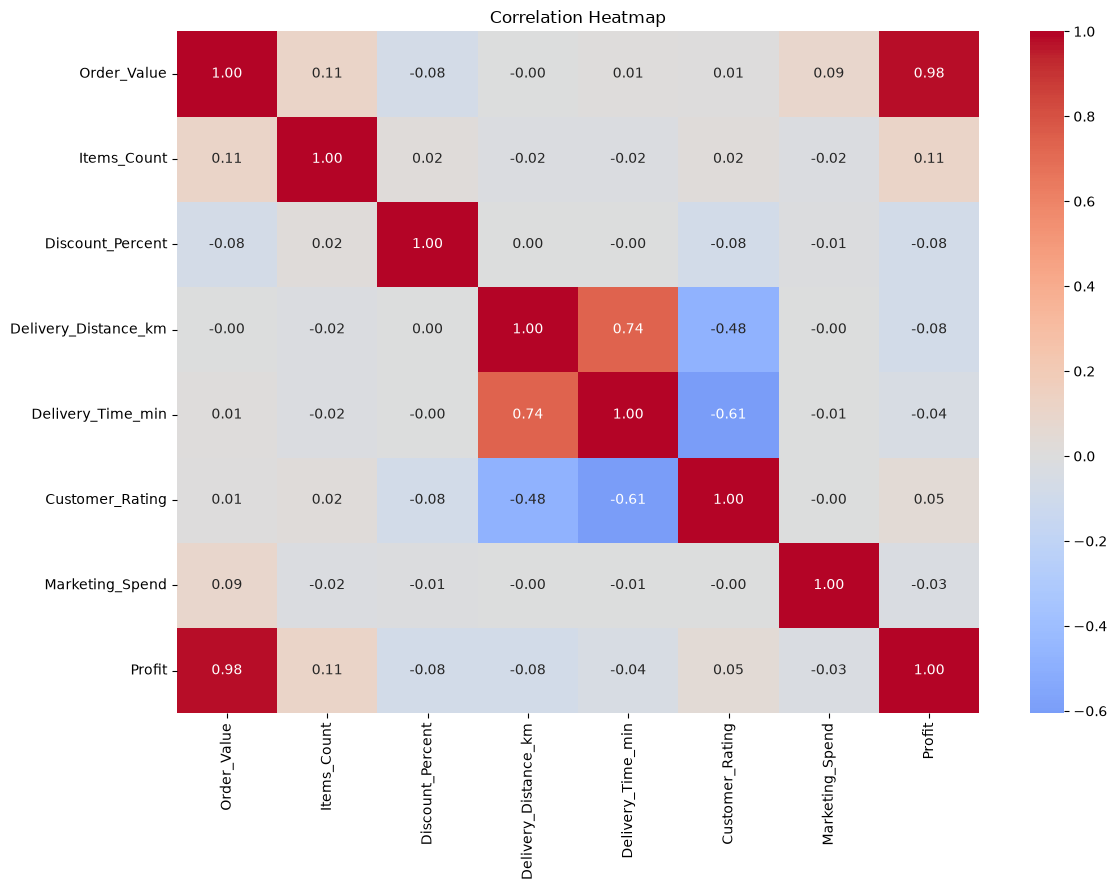

In [33]:
# STEP 30: Correlation Heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "11_correlation_heatmap.png"), dpi=200)
plt.show()
plt.close()


In [35]:
# STEP 31: Linear Regression
# Independent variable: Marketing_Spend
# Dependent variable: Order_Value

reg_df = df_clean[["Marketing_Spend", "Order_Value"]].dropna()

X = reg_df[["Marketing_Spend"]]
y = reg_df["Order_Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

regression_model = LinearRegression()
regression_model.fit(X_train, y_train)

predictions = regression_model.predict(X_test)

print(
    f"Regression equation: "
    f"Order_Value = {regression_model.intercept_:.2f} + "
    f"{regression_model.coef_[0]:.4f} * Marketing_Spend"
)
print("Coefficient:", round(regression_model.coef_[0], 4))
print("R²:", round(r2_score(y_test, predictions), 4))
print("MSE:", round(mean_squared_error(y_test, predictions), 2))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, predictions)), 2))


Regression equation: Order_Value = 276.68 + 0.1273 * Marketing_Spend
Coefficient: 0.1273
R²: 0.0017
MSE: 68445.06
RMSE: 261.62


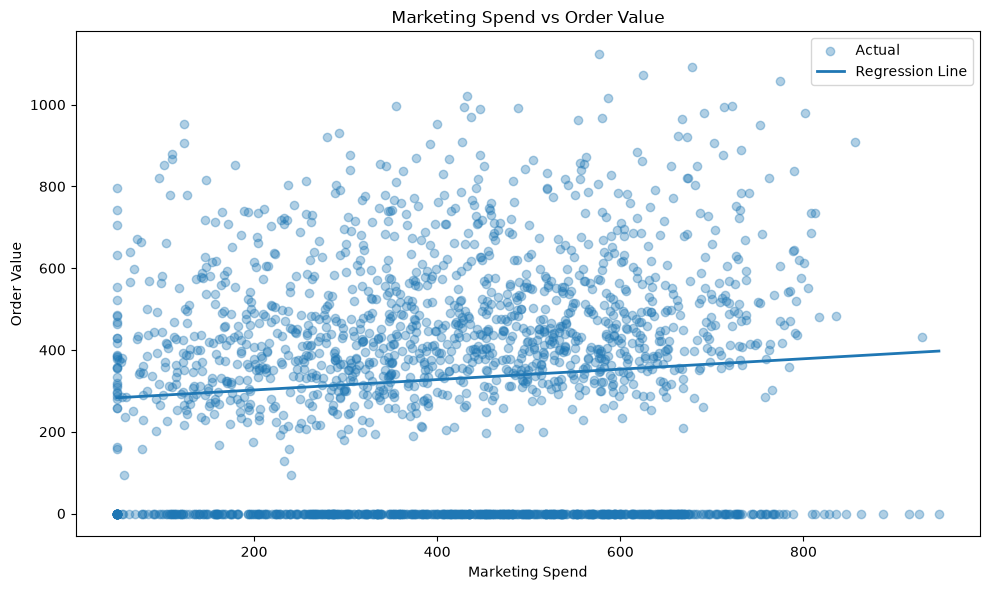

Predicted Order Value for Marketing Spend ₹600: 353.06


In [36]:
# STEP 32: Regression Scatter Plot + Regression Line
plot_data = pd.DataFrame({
    "Marketing_Spend": X_test["Marketing_Spend"].values,
    "Actual": y_test.values,
    "Predicted": predictions
}).sort_values("Marketing_Spend")

plt.figure(figsize=(10, 6))
plt.scatter(
    plot_data["Marketing_Spend"],
    plot_data["Actual"],
    alpha=0.35,
    label="Actual"
)
plt.plot(
    plot_data["Marketing_Spend"],
    plot_data["Predicted"],
    linewidth=2,
    label="Regression Line"
)
plt.title("Marketing Spend vs Order Value")
plt.xlabel("Marketing Spend")
plt.ylabel("Order Value")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "12_regression_marketing_spend_order_value.png"),
    dpi=200
)
plt.show()
plt.close()

example_spend = np.array([[600]])
example_prediction = regression_model.predict(example_spend)[0]

print(
    "Predicted Order Value for Marketing Spend ₹600:",
    round(example_prediction, 2)
)


In [37]:
# STEP 33: Probability Analysis
p_completed = df_clean["Order_Status"].eq("Completed").mean()
p_converted = df_clean["Conversion_Status"].eq("Converted").mean()
p_refund = df_clean["Returned_Refund"].mean()

print("P(Completed Order):", round(p_completed, 4))
print("P(Converted):", round(p_converted, 4))
print("P(Return/Refund):", round(p_refund, 4))

print("\nCompletion probability by Peak_Hour:")
print(
    df_clean.groupby("Peak_Hour")["Order_Status"]
    .apply(lambda s: (s == "Completed").mean())
    .round(4)
)


P(Completed Order): 0.6845
P(Converted): 0.7461
P(Return/Refund): 0.025

Completion probability by Peak_Hour:
Peak_Hour
Off-Peak    0.7013
Peak        0.6573
Name: Order_Status, dtype: float64


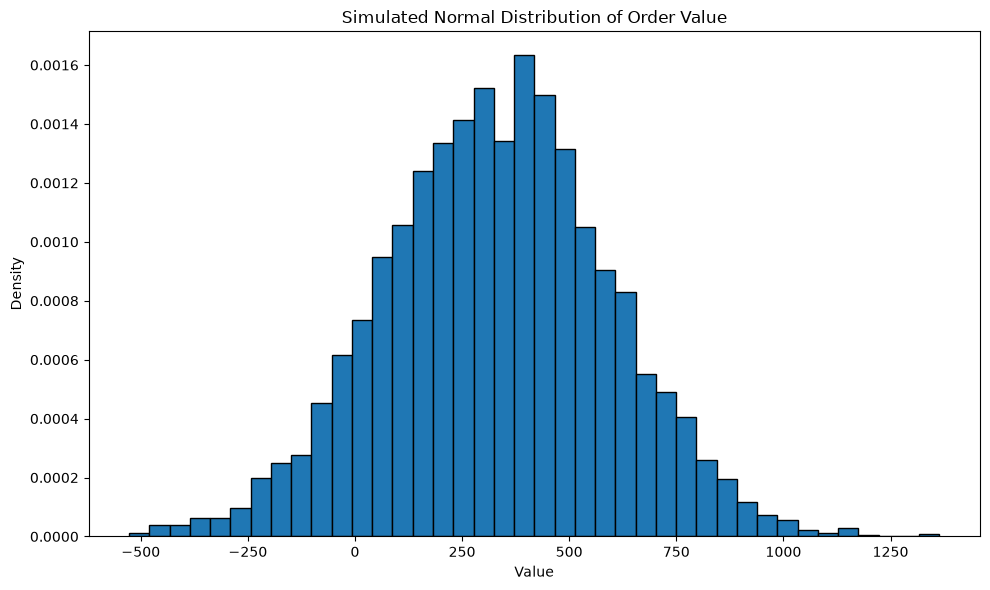

In [38]:
# STEP 34: Probability Distribution – Normal
np.random.seed(42)

mu = df_clean["Order_Value"].mean()
sigma = df_clean["Order_Value"].std()

normal_sample = np.random.normal(mu, sigma, 5000)

plt.figure(figsize=(10, 6))
plt.hist(normal_sample, bins=40, density=True, edgecolor="black")
plt.title("Simulated Normal Distribution of Order Value")
plt.xlabel("Value")
plt.ylabel("Density")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "13_normal_distribution.png"), dpi=200)
plt.show()
plt.close()


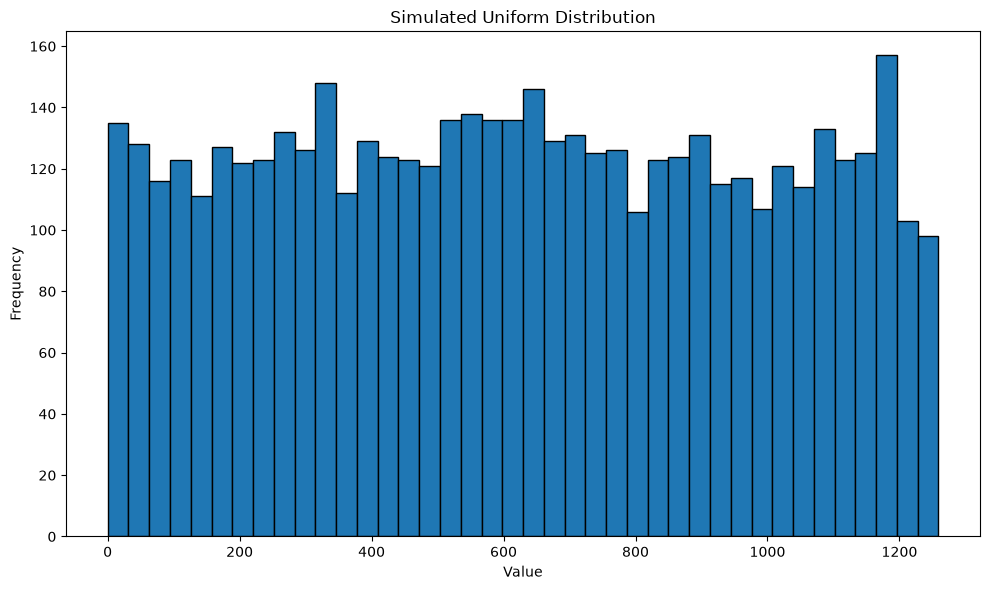

In [39]:
# STEP 35: Probability Distribution – Uniform
low = float(df_clean["Order_Value"].min())
high = float(df_clean["Order_Value"].max())

uniform_sample = np.random.uniform(low, high, 5000)

plt.figure(figsize=(10, 6))
plt.hist(uniform_sample, bins=40, edgecolor="black")
plt.title("Simulated Uniform Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "14_uniform_distribution.png"), dpi=200)
plt.show()
plt.close()


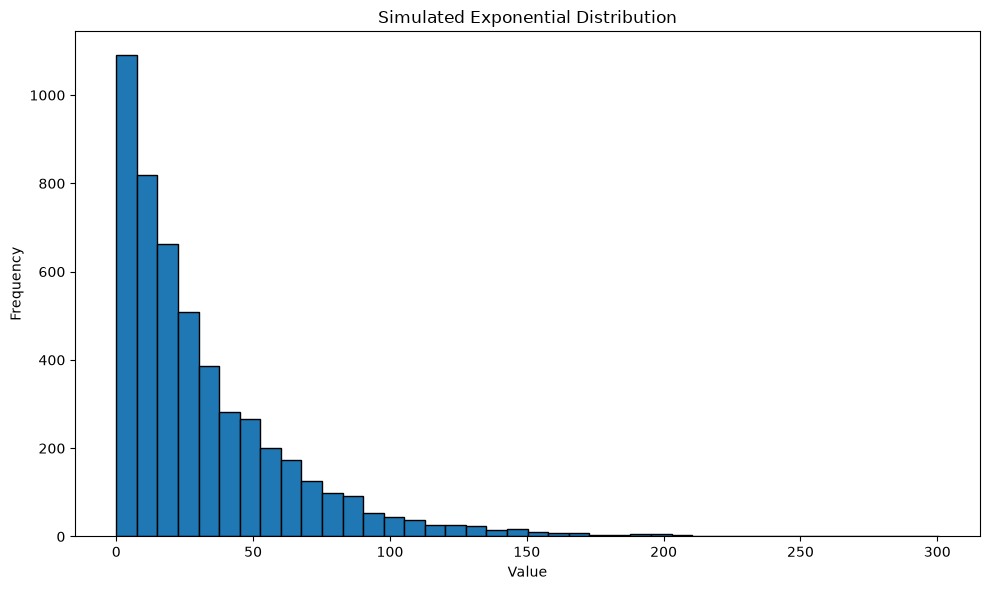

In [40]:
# STEP 36: Probability Distribution – Exponential
scale = max(float(df_clean["Delivery_Time_min"].mean()), 1.0)

exponential_sample = np.random.exponential(
    scale=scale,
    size=5000
)

plt.figure(figsize=(10, 6))
plt.hist(exponential_sample, bins=40, edgecolor="black")
plt.title("Simulated Exponential Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "15_exponential_distribution.png"), dpi=200)
plt.show()
plt.close()


In [41]:
# STEP 37: Decision Making Under Uncertainty – Expected Value
channel_mean = (
    df_clean.groupby("Marketing_Channel")["Order_Value"]
    .mean()
)

probabilities = {
    "High": 0.25,
    "Medium": 0.50,
    "Low": 0.25
}

payoff_multipliers = {
    "Social Media": {"High": 1.25, "Medium": 1.00, "Low": 0.75},
    "Email": {"High": 1.22, "Medium": 1.00, "Low": 0.80},
    "Online Ads": {"High": 1.30, "Medium": 1.00, "Low": 0.70},
    "Referral": {"High": 1.18, "Medium": 1.00, "Low": 0.85}
}

decision_rows = []

for channel in payoff_multipliers:
    base = channel_mean[channel]

    high_payoff = base * payoff_multipliers[channel]["High"]
    medium_payoff = base * payoff_multipliers[channel]["Medium"]
    low_payoff = base * payoff_multipliers[channel]["Low"]

    expected_value = (
        probabilities["High"] * high_payoff
        + probabilities["Medium"] * medium_payoff
        + probabilities["Low"] * low_payoff
    )

    decision_rows.append([
        channel,
        high_payoff,
        medium_payoff,
        low_payoff,
        expected_value
    ])

decision_df = pd.DataFrame(
    decision_rows,
    columns=[
        "Marketing Channel",
        "High Payoff",
        "Medium Payoff",
        "Low Payoff",
        "Expected Value"
    ]
)

print(decision_df.round(2))

best_channel = decision_df.loc[
    decision_df["Expected Value"].idxmax(),
    "Marketing Channel"
]

print("Recommended channel:", best_channel)


  Marketing Channel  High Payoff  Medium Payoff  Low Payoff  Expected Value
0      Social Media       398.49         318.79      239.09          318.79
1             Email       368.23         301.82      241.46          303.33
2        Online Ads       467.80         359.85      251.89          359.85
3          Referral       372.41         315.60      268.26          317.97
Recommended channel: Online Ads


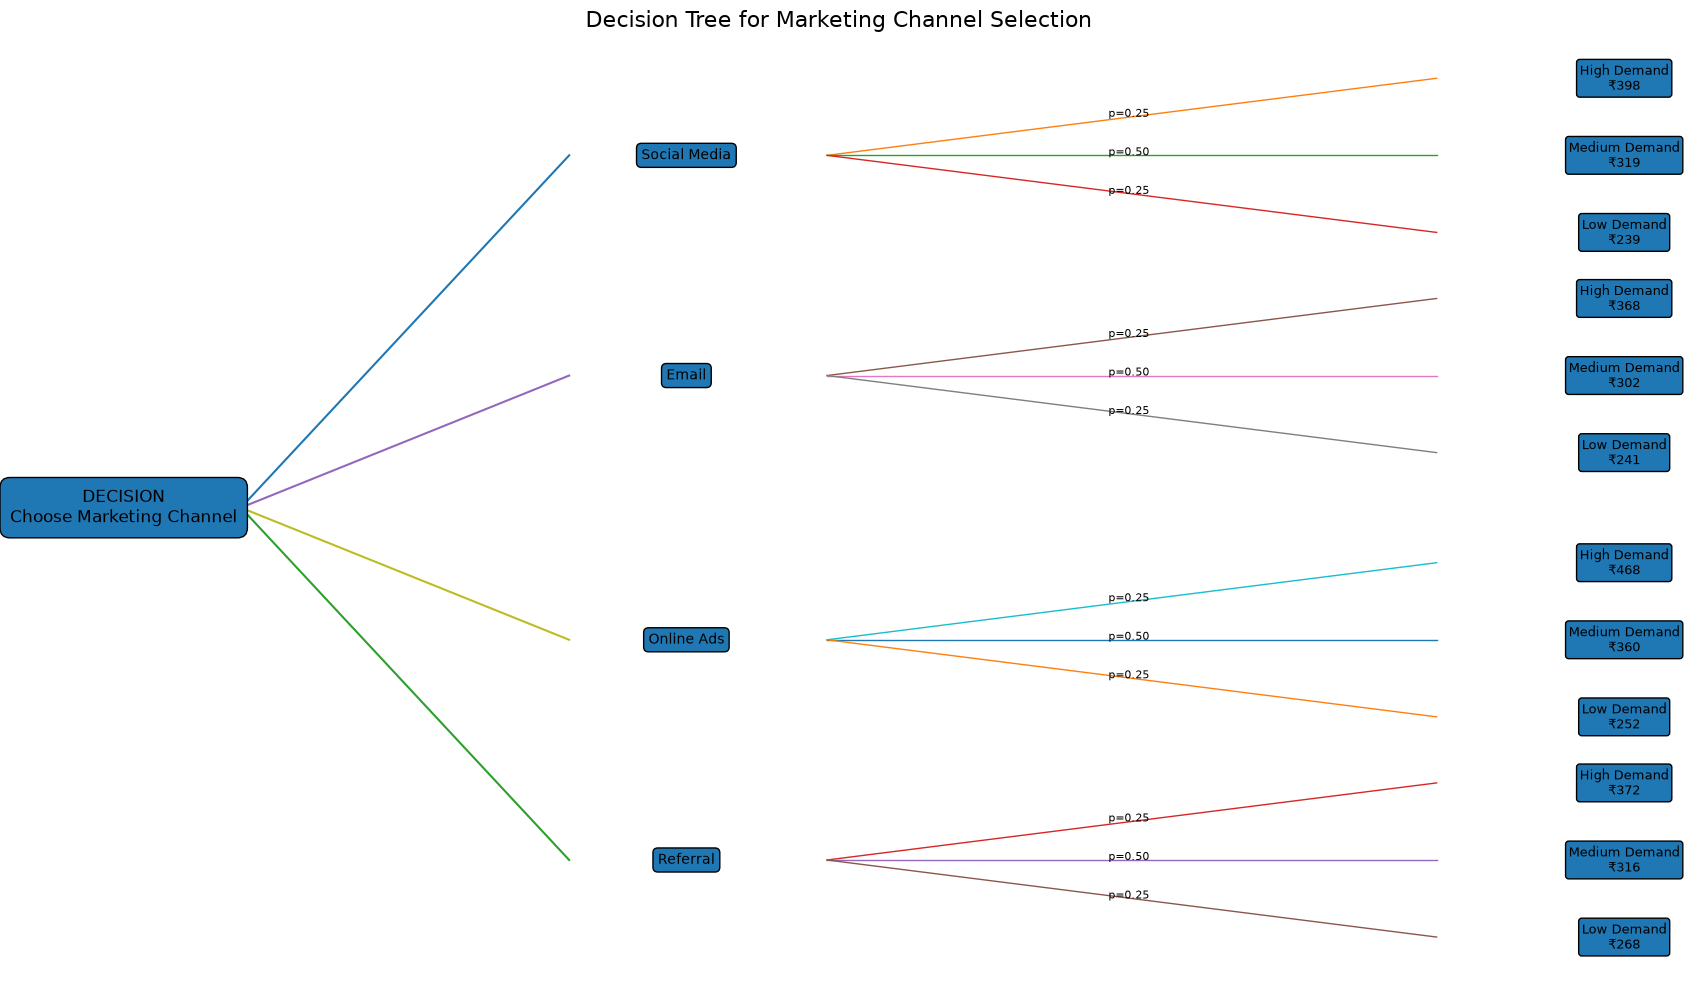

In [42]:
# STEP 38: Decision Tree
fig, ax = plt.subplots(figsize=(17, 10))
ax.axis("off")

decision_x = 0.08
channel_x = 0.32
outcome_x = 0.72

ax.text(
    decision_x, 0.50,
    "DECISION\nChoose Marketing Channel",
    ha="center",
    va="center",
    fontsize=12,
    bbox=dict(boxstyle="round,pad=0.6")
)

channel_positions = {
    "Social Media": 0.82,
    "Email": 0.62,
    "Online Ads": 0.38,
    "Referral": 0.18
}

for channel, y0 in channel_positions.items():

    ax.plot(
        [decision_x + 0.05, channel_x - 0.05],
        [0.50, y0],
        linewidth=1.5
    )

    ax.text(
        channel_x, y0, channel,
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35")
    )

    base = channel_mean[channel]

    outcomes = ["High", "Medium", "Low"]
    outcome_positions = [y0 + 0.07, y0, y0 - 0.07]

    for outcome, yy in zip(outcomes, outcome_positions):

        payoff = base * payoff_multipliers[channel][outcome]

        ax.plot(
            [channel_x + 0.06, outcome_x - 0.08],
            [y0, yy],
            linewidth=1
        )

        ax.text(
            0.50,
            (y0 + yy) / 2,
            f"p={probabilities[outcome]:.2f}",
            fontsize=8
        )

        ax.text(
            outcome_x,
            yy,
            f"{outcome} Demand\n₹{payoff:,.0f}",
            ha="center",
            va="center",
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.25")
        )

ax.set_title(
    "Decision Tree for Marketing Channel Selection",
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "16_decision_tree.png"),
    dpi=200,
    bbox_inches="tight"
)
plt.show()
plt.close()


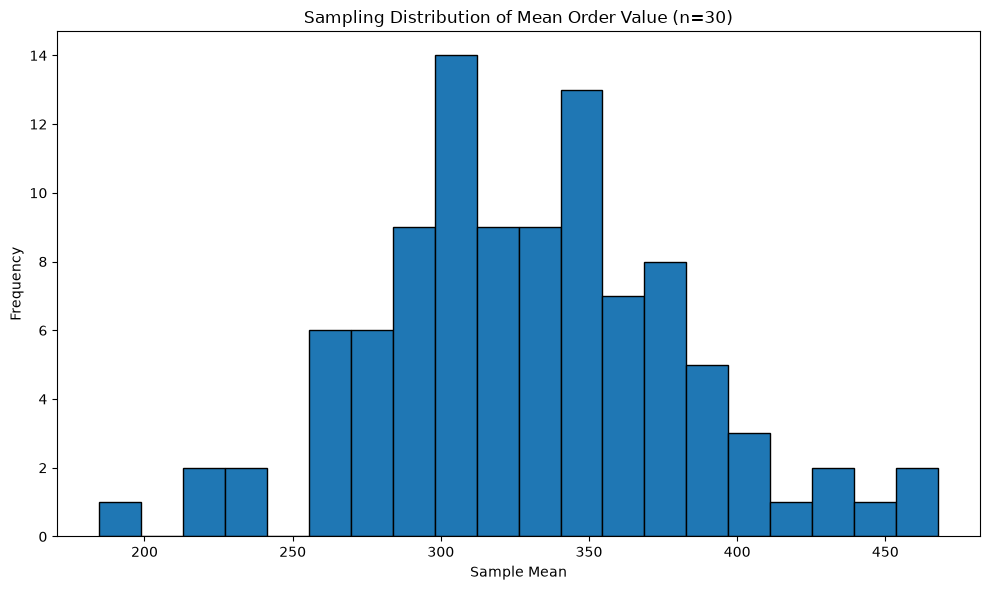

   Sample Size  Mean of Sample Means  SD of Sample Means  Standard Error
0           30               329.430              51.935          48.177
1           50               331.219              38.633          37.318
2          100               328.908              27.871          26.387


In [43]:
# STEP 39: Sampling Distribution
population = df_clean["Order_Value"].dropna()

sample_sizes = [30, 50, 100]
sampling_rows = []

for sample_size in sample_sizes:

    sample_means = [
        population.sample(
            sample_size,
            random_state=1000 + i
        ).mean()
        for i in range(100)
    ]

    sampling_rows.append([
        sample_size,
        np.mean(sample_means),
        np.std(sample_means, ddof=1),
        population.std() / np.sqrt(sample_size)
    ])

    if sample_size == 30:
        plt.figure(figsize=(10, 6))
        plt.hist(sample_means, bins=20, edgecolor="black")
        plt.title("Sampling Distribution of Mean Order Value (n=30)")
        plt.xlabel("Sample Mean")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.savefig(
            os.path.join(OUT_DIR, "17_sampling_distribution_n30.png"),
            dpi=200
        )
        plt.show()
        plt.close()

sampling_df = pd.DataFrame(
    sampling_rows,
    columns=[
        "Sample Size",
        "Mean of Sample Means",
        "SD of Sample Means",
        "Standard Error"
    ]
)

print(sampling_df.round(3))


In [45]:
# STEP 40: Confidence Intervals – 90%, 95%, 99%
sample_mean = population.mean()
sample_sem = stats.sem(population)

confidence_rows = []

for confidence in [0.90, 0.95, 0.99]:

    lower_ci, upper_ci = stats.t.interval(
        confidence,
        df=len(population) - 1,
        loc=sample_mean,
        scale=sample_sem
    )

    confidence_rows.append([
        int(confidence * 100),
        lower_ci,
        upper_ci
    ])

confidence_df = pd.DataFrame(
    confidence_rows,
    columns=["Confidence Level", "Lower Bound", "Upper Bound"]
)

print(confidence_df.round(2))


   Confidence Level  Lower Bound  Upper Bound
0                90       323.86       332.54
1                95       323.03       333.38
2                99       321.41       335.00


Original median: 363.2
Bootstrap 95% CI: 357.64 to 368.15


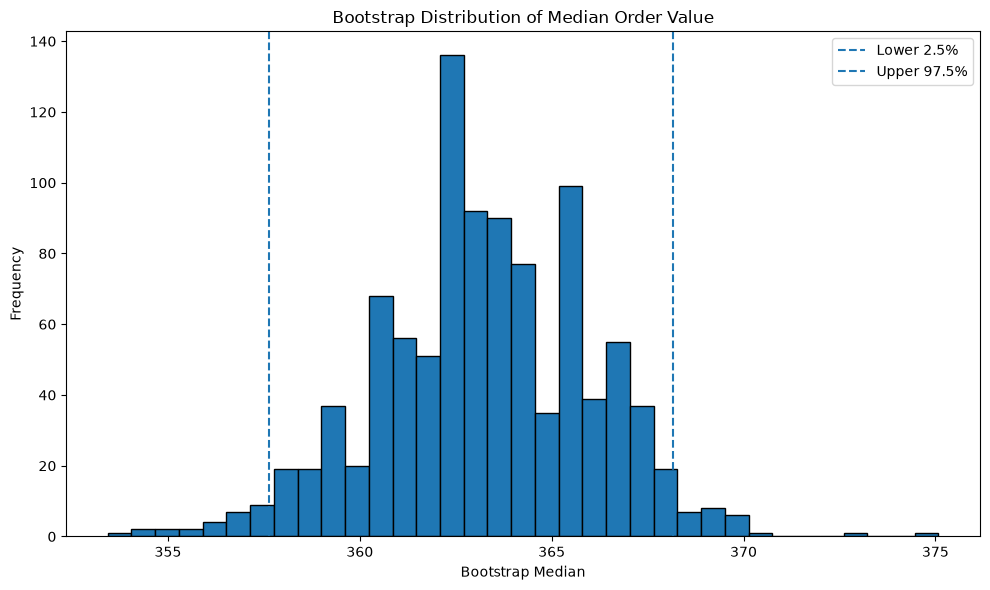

In [46]:
# STEP 41: Bootstrapping – 1000 samples
rng = np.random.default_rng(42)
population_values = population.to_numpy()

bootstrap_medians = []

for _ in range(1000):
    bootstrap_sample = rng.choice(
        population_values,
        size=len(population_values),
        replace=True
    )

    bootstrap_medians.append(
        np.median(bootstrap_sample)
    )

bootstrap_medians = np.array(bootstrap_medians)

bootstrap_ci = np.percentile(
    bootstrap_medians,
    [2.5, 97.5]
)

print("Original median:", round(np.median(population_values), 2))
print("Bootstrap 95% CI:",
      round(bootstrap_ci[0], 2),
      "to",
      round(bootstrap_ci[1], 2))

plt.figure(figsize=(10, 6))
plt.hist(bootstrap_medians, bins=35, edgecolor="black")
plt.axvline(
    bootstrap_ci[0],
    linestyle="--",
    label="Lower 2.5%"
)
plt.axvline(
    bootstrap_ci[1],
    linestyle="--",
    label="Upper 97.5%"
)
plt.title("Bootstrap Distribution of Median Order Value")
plt.xlabel("Bootstrap Median")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "18_bootstrap_distribution.png"),
    dpi=200
)
plt.show()
plt.close()


In [47]:
# STEP 42: Hypothesis Testing
# Business question:
# Is average order value significantly different from ₹500?

hypothesized_mean = 500

t_statistic, p_value = stats.ttest_1samp(
    population,
    hypothesized_mean
)

print("H0: Mean Order Value = ₹500")
print("H1: Mean Order Value != ₹500")
print("Significance level = 0.05")
print("t-statistic:", round(t_statistic, 4))
print("p-value:", p_value)

if p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


H0: Mean Order Value = ₹500
H1: Mean Order Value != ₹500
Significance level = 0.05
t-statistic: -65.1051
p-value: 0.0
Decision: Reject H0


In [48]:
# STEP 43: A/B Testing – Conversion Rate
# A = Buy Now
# B = Get Started

ab_counts = (
    df_clean.groupby("Landing_Page_Version")["Conversion_Status"]
    .apply(lambda s: (s == "Converted").sum())
)

ab_totals = df_clean.groupby("Landing_Page_Version").size()

count = np.array([
    ab_counts["A - Buy Now"],
    ab_counts["B - Get Started"]
])

nobs = np.array([
    ab_totals["A - Buy Now"],
    ab_totals["B - Get Started"]
])

z_statistic, ab_p_value = proportions_ztest(
    count,
    nobs
)

conversion_rate_a = count[0] / nobs[0]
conversion_rate_b = count[1] / nobs[1]

print("Version A conversion rate:", round(conversion_rate_a * 100, 2), "%")
print("Version B conversion rate:", round(conversion_rate_b * 100, 2), "%")
print("z-statistic:", round(z_statistic, 4))
print("p-value:", ab_p_value)

if ab_p_value < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


Version A conversion rate: 72.02 %
Version B conversion rate: 77.16 %
z-statistic: -5.9012
p-value: 3.6084514280350794e-09
Decision: Reject H0


           Version  Conversion Rate
0      A - Buy Now         0.720194
1  B - Get Started         0.771565


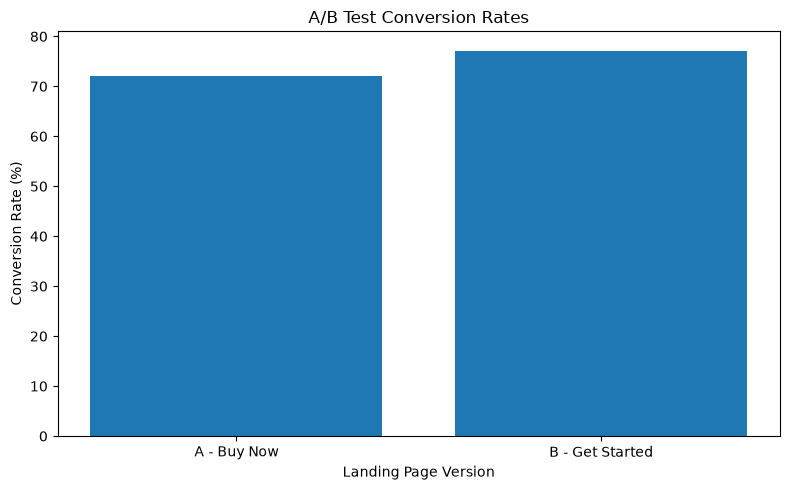

In [49]:
# STEP 44: A/B Test Chart
ab_summary = pd.DataFrame({
    "Version": ["A - Buy Now", "B - Get Started"],
    "Conversion Rate": [
        conversion_rate_a,
        conversion_rate_b
    ]
})

print(ab_summary)

plt.figure(figsize=(8, 5))
plt.bar(
    ab_summary["Version"],
    ab_summary["Conversion Rate"] * 100
)
plt.title("A/B Test Conversion Rates")
plt.xlabel("Landing Page Version")
plt.ylabel("Conversion Rate (%)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "19_ab_test_conversion_rates.png"),
    dpi=200
)
plt.show()
plt.close()


Order_Date
2025-01-01    154498.98
2025-02-01    165939.20
2025-03-01    158843.45
2025-04-01    164709.98
2025-05-01    188777.24
2025-06-01    165034.10
2025-07-01    161562.08
2025-08-01    160109.26
2025-09-01    144349.75
2025-10-01    147161.33
2025-11-01    142380.71
2025-12-01    151105.68
2026-01-01    165239.80
2026-02-01    167998.61
2026-03-01    173426.42
2026-04-01    197375.02
2026-05-01    182062.09
2026-06-01    160979.79
2026-07-01    170998.93
2026-08-01    159488.45
Freq: MS, Name: Order_Value, dtype: float64


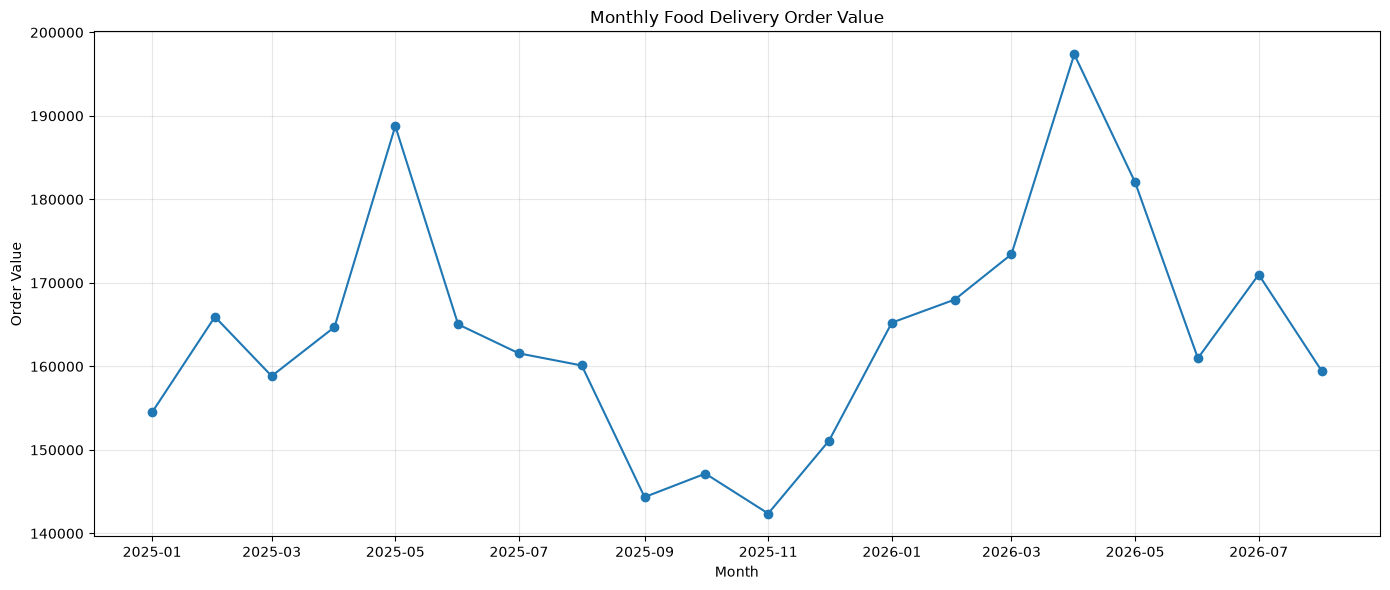

In [50]:
# STEP 45: Time Series – Monthly Order Value
monthly_sales = (
    df_clean.set_index("Order_Date")["Order_Value"]
    .resample("MS")
    .sum()
)

print(monthly_sales.round(2))

plt.figure(figsize=(14, 6))
plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o"
)
plt.title("Monthly Food Delivery Order Value")
plt.xlabel("Month")
plt.ylabel("Order Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "20_monthly_sales_time_series.png"),
    dpi=200
)
plt.show()
plt.close()


In [51]:
# STEP 46: Trend Analysis
first_month = monthly_sales.iloc[0]
last_month = monthly_sales.iloc[-1]

trend_percent = (
    (last_month - first_month) / first_month
) * 100

print("First month sales:", round(first_month, 2))
print("Last month sales :", round(last_month, 2))
print("Overall change   :", round(trend_percent, 2), "%")


First month sales: 154498.98
Last month sales : 159488.45
Overall change   : 3.23 %


Month_Number
1     159869.39
2     166968.91
3     166134.94
4     181042.50
5     185419.66
6     163006.94
7     166280.50
8     159798.86
9     144349.75
10    147161.33
11    142380.71
12    151105.68
Name: Sales, dtype: float64


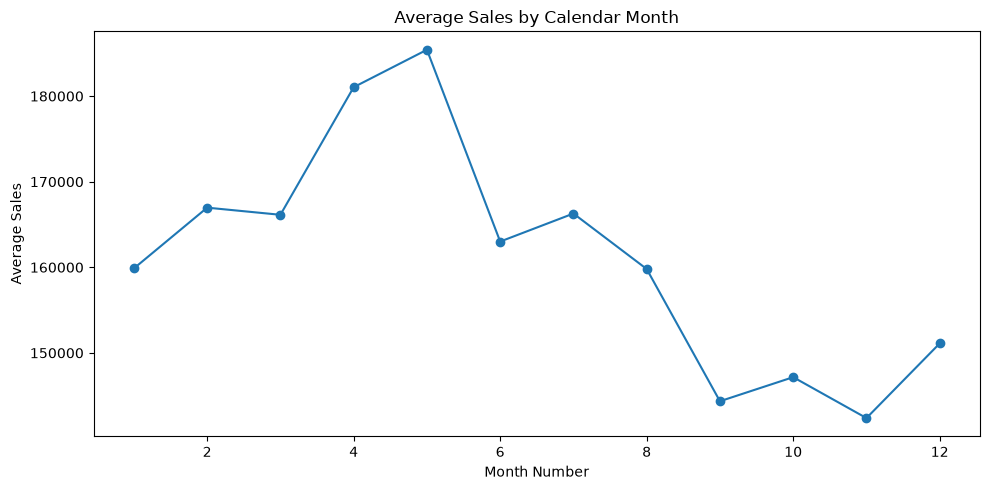

In [52]:
# STEP 47: Seasonality Analysis
seasonality_df = monthly_sales.to_frame("Sales")
seasonality_df["Month_Number"] = seasonality_df.index.month

seasonal_average = (
    seasonality_df
    .groupby("Month_Number")["Sales"]
    .mean()
)

print(seasonal_average.round(2))

plt.figure(figsize=(10, 5))
plt.plot(
    seasonal_average.index,
    seasonal_average.values,
    marker="o"
)
plt.title("Average Sales by Calendar Month")
plt.xlabel("Month Number")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "21_seasonality_pattern.png"),
    dpi=200
)
plt.show()
plt.close()


In [53]:
# STEP 48: Exponential Smoothing (Holt)
train = monthly_sales.iloc[:-4]
test = monthly_sales.iloc[-4:]

holt_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

holt_forecast = holt_model.forecast(len(test))

print("Holt forecast:")
print(holt_forecast.round(2))


Holt forecast:
2026-05-01    195697.14
2026-06-01    197786.54
2026-07-01    199875.93
2026-08-01    201965.33
Freq: MS, dtype: float64


In [54]:
# STEP 49: ARIMA(1,1,1)
arima_model = ARIMA(
    train,
    order=(1, 1, 1)
).fit()

arima_forecast = arima_model.forecast(len(test))

print("ARIMA forecast:")
print(arima_forecast.round(2))


ARIMA forecast:
2026-05-01    198961.32
2026-06-01    198490.26
2026-07-01    198630.14
2026-08-01    198588.60
Freq: MS, Name: predicted_mean, dtype: float64


               Actual       Holt      ARIMA
2026-05-01  182062.09  195697.14  198961.32
2026-06-01  160979.79  197786.54  198490.26
2026-07-01  170998.93  199875.93  198630.14
2026-08-01  159488.45  201965.33  198588.60


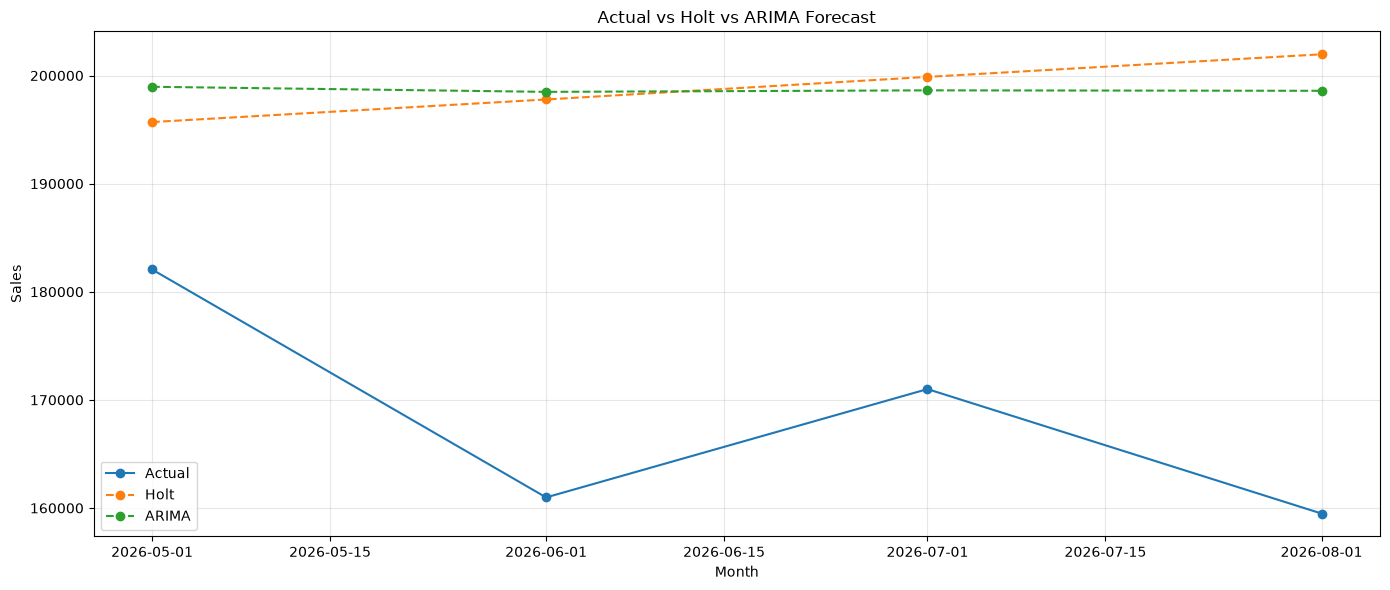

In [55]:
# STEP 50: Compare Actual vs Holt vs ARIMA
forecast_comparison = pd.DataFrame({
    "Actual": test,
    "Holt": holt_forecast,
    "ARIMA": arima_forecast
})

print(forecast_comparison.round(2))

plt.figure(figsize=(14, 6))
plt.plot(
    forecast_comparison.index,
    forecast_comparison["Actual"],
    marker="o",
    label="Actual"
)
plt.plot(
    forecast_comparison.index,
    forecast_comparison["Holt"],
    marker="o",
    linestyle="--",
    label="Holt"
)
plt.plot(
    forecast_comparison.index,
    forecast_comparison["ARIMA"],
    marker="o",
    linestyle="--",
    label="ARIMA"
)
plt.title("Actual vs Holt vs ARIMA Forecast")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "22_forecast_comparison.png"),
    dpi=200
)
plt.show()
plt.close()


In [56]:
# STEP 51: Forecast Accuracy
holt_mae = mean_absolute_error(test, holt_forecast)
holt_mse = mean_squared_error(test, holt_forecast)
holt_rmse = np.sqrt(holt_mse)

arima_mae = mean_absolute_error(test, arima_forecast)
arima_mse = mean_squared_error(test, arima_forecast)
arima_rmse = np.sqrt(arima_mse)

forecast_accuracy = pd.DataFrame({
    "Model": [
        "Holt Exponential Smoothing",
        "ARIMA(1,1,1)"
    ],
    "MAE": [
        holt_mae,
        arima_mae
    ],
    "MSE": [
        holt_mse,
        arima_mse
    ],
    "RMSE": [
        holt_rmse,
        arima_rmse
    ]
})

print(forecast_accuracy.round(2))

best_model = forecast_accuracy.loc[
    forecast_accuracy["RMSE"].idxmin(),
    "Model"
]

print("Best forecasting model:", best_model)

forecast_accuracy.to_csv(
    os.path.join(OUT_DIR, "07_forecast_accuracy.csv"),
    index=False
)


                        Model       MAE           MSE      RMSE
0  Holt Exponential Smoothing  30448.92  1.044705e+09  32321.89
1                ARIMA(1,1,1)  30285.27  9.962314e+08  31563.13
Best forecasting model: ARIMA(1,1,1)


In [57]:
# STEP 52: Future 4-Month Forecast
full_holt_model = ExponentialSmoothing(
    monthly_sales,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit()

future_holt = full_holt_model.forecast(4)

full_arima_model = ARIMA(
    monthly_sales,
    order=(1, 1, 1)
).fit()

future_arima = full_arima_model.forecast(4)

future_forecast = pd.DataFrame({
    "Holt Forecast": future_holt,
    "ARIMA Forecast": future_arima
})

print(future_forecast.round(2))
future_forecast.to_csv(
    os.path.join(OUT_DIR, "08_future_forecast.csv")
)


            Holt Forecast  ARIMA Forecast
2026-09-01      162054.26       158343.66
2026-10-01      161927.31       158780.33
2026-11-01      161800.36       158613.76
2026-12-01      161673.41       158677.30


In [58]:
# STEP 53: Optimization Modeling
# Business problem:
# maximize contribution profit from weekly food bundles
# subject to budget, storage and labor constraints.

products = np.array([
    "Burger Meal",
    "Pizza Combo",
    "Biryani Box",
    "Healthy Bowl"
])

profit_per_unit = np.array([110, 145, 125, 100], dtype=float)
budget_per_unit = np.array([180, 260, 220, 160], dtype=float)
storage_per_unit = np.array([1.0, 1.3, 1.1, 0.9], dtype=float)
labor_per_unit = np.array([0.8, 1.1, 0.9, 0.7], dtype=float)

budget_limit = 50000
storage_limit = 300
labor_limit = 220

objective = -profit_per_unit

A = np.vstack([
    budget_per_unit,
    storage_per_unit,
    labor_per_unit
])

b = np.array([
    budget_limit,
    storage_limit,
    labor_limit
])

bounds = [
    (0, 180),
    (0, 150),
    (0, 160),
    (0, 180)
]

optimization_result = linprog(
    objective,
    A_ub=A,
    b_ub=b,
    bounds=bounds,
    method="highs"
)

if optimization_result.success:

    optimal_quantity = optimization_result.x
    maximum_profit = -optimization_result.fun

    print("Optimal quantities:")
    for product, qty in zip(products, optimal_quantity):
        print(product, ":", round(qty, 2))

    print("Maximum Profit:", round(maximum_profit, 2))

    used_budget = np.dot(
        budget_per_unit,
        optimal_quantity
    )

    used_storage = np.dot(
        storage_per_unit,
        optimal_quantity
    )

    used_labor = np.dot(
        labor_per_unit,
        optimal_quantity
    )

    print("Budget Used:", round(used_budget, 2))
    print("Storage Used:", round(used_storage, 2))
    print("Labor Used:", round(used_labor, 2))

else:
    print("Optimization failed:", optimization_result.message)


Optimal quantities:
Burger Meal : 114.29
Pizza Combo : 0.0
Biryani Box : 2.86
Healthy Bowl : 180.0
Maximum Profit: 30928.57
Budget Used: 50000.0
Storage Used: 279.43
Labor Used: 220.0


In [59]:
# STEP 54: Save Optimization Results
optimization_df = pd.DataFrame({
    "Product": products,
    "Optimal Quantity": optimal_quantity,
    "Profit per Unit": profit_per_unit,
    "Budget per Unit": budget_per_unit,
    "Storage per Unit": storage_per_unit,
    "Labor per Unit": labor_per_unit
})

print(optimization_df.round(2))

optimization_df.to_csv(
    os.path.join(OUT_DIR, "09_optimization_results.csv"),
    index=False
)


        Product  Optimal Quantity  Profit per Unit  Budget per Unit  \
0   Burger Meal            114.29            110.0            180.0   
1   Pizza Combo              0.00            145.0            260.0   
2   Biryani Box              2.86            125.0            220.0   
3  Healthy Bowl            180.00            100.0            160.0   

   Storage per Unit  Labor per Unit  
0               1.0             0.8  
1               1.3             1.1  
2               1.1             0.9  
3               0.9             0.7  


In [60]:
# STEP 55: Simulation Modeling
# Three demand scenarios:
# Low, Normal, High

rng = np.random.default_rng(42)

scenarios = {
    "Low Demand": 700,
    "Normal Demand": 1000,
    "High Demand": 1300
}

initial_inventory = 1100
selling_price = 420
unit_cost = 240

simulation_rows = []

for scenario_name, mean_demand in scenarios.items():

    demand = rng.normal(
        loc=mean_demand,
        scale=mean_demand * 0.15,
        size=500
    )

    demand = np.maximum(demand, 0)

    units_sold = np.minimum(
        demand,
        initial_inventory
    )

    shortage = np.maximum(
        demand - initial_inventory,
        0
    )

    revenue = units_sold * selling_price
    cost = units_sold * unit_cost
    profit = revenue - cost

    service_level = (
        units_sold / np.maximum(demand, 1)
    )

    simulation_rows.append([
        scenario_name,
        demand.mean(),
        shortage.mean(),
        units_sold.mean(),
        profit.mean(),
        service_level.mean()
    ])

simulation_df = pd.DataFrame(
    simulation_rows,
    columns=[
        "Scenario",
        "Average Demand",
        "Average Shortage",
        "Average Units Sold",
        "Average Profit",
        "Service Level"
    ]
)

print(simulation_df.round(2))


        Scenario  Average Demand  Average Shortage  Average Units Sold  \
0     Low Demand          698.62              0.00              698.62   
1  Normal Demand          993.30             20.88              972.43   
2    High Demand         1299.24            216.79             1082.45   

   Average Profit  Service Level  
0       125751.92           1.00  
1       175036.68           0.98  
2       194840.32           0.85  


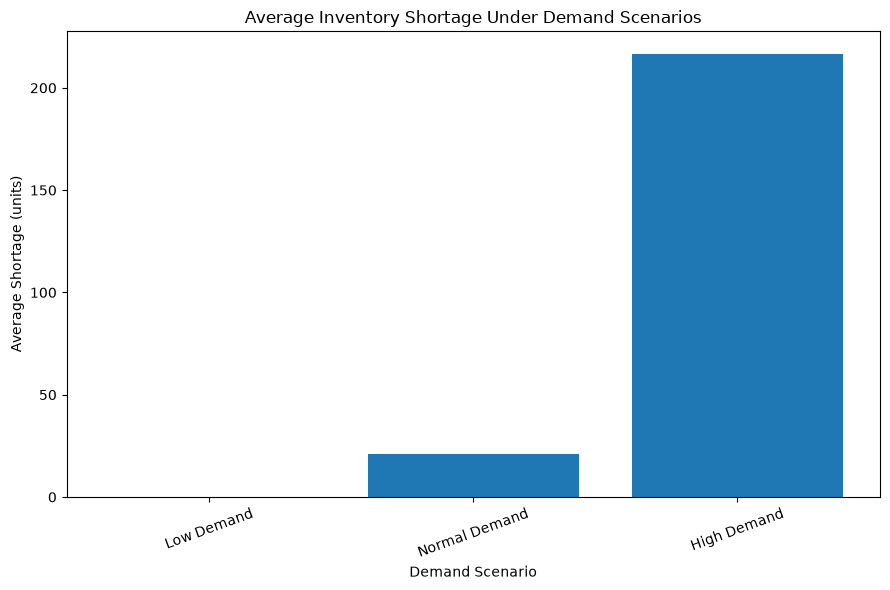

In [61]:
# STEP 56: Simulation Comparison Chart
plt.figure(figsize=(9, 6))

plt.bar(
    simulation_df["Scenario"],
    simulation_df["Average Shortage"]
)

plt.title("Average Inventory Shortage Under Demand Scenarios")
plt.xlabel("Demand Scenario")
plt.ylabel("Average Shortage (units)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.savefig(
    os.path.join(OUT_DIR, "23_simulation_shortage.png"),
    dpi=200
)

plt.show()
plt.close()

simulation_df.to_csv(
    os.path.join(OUT_DIR, "10_simulation_results.csv"),
    index=False
)


In [62]:
# STEP 57: One-Way ANOVA
# Business question:
# Does average order value differ across marketing channels?

anova_data = df_clean[
    ["Marketing_Channel", "Order_Value"]
].dropna()

anova_groups = [
    group["Order_Value"].values
    for _, group in anova_data.groupby("Marketing_Channel")
]

anova_f, anova_p = stats.f_oneway(*anova_groups)

print("H0: All marketing channel means are equal")
print("H1: At least one mean is different")
print("F-statistic:", round(anova_f, 4))
print("p-value:", anova_p)

if anova_p < 0.05:
    print("Decision: Reject H0")
else:
    print("Decision: Fail to reject H0")


H0: All marketing channel means are equal
H1: At least one mean is different
F-statistic: 23.9653
p-value: 1.899154723996879e-15
Decision: Reject H0


                            sum_sq      df         F        PR(>F)
C(Marketing_Channel)  4.971847e+06     3.0  23.96531  1.899155e-15
Residual              6.912572e+08  9996.0       NaN           NaN


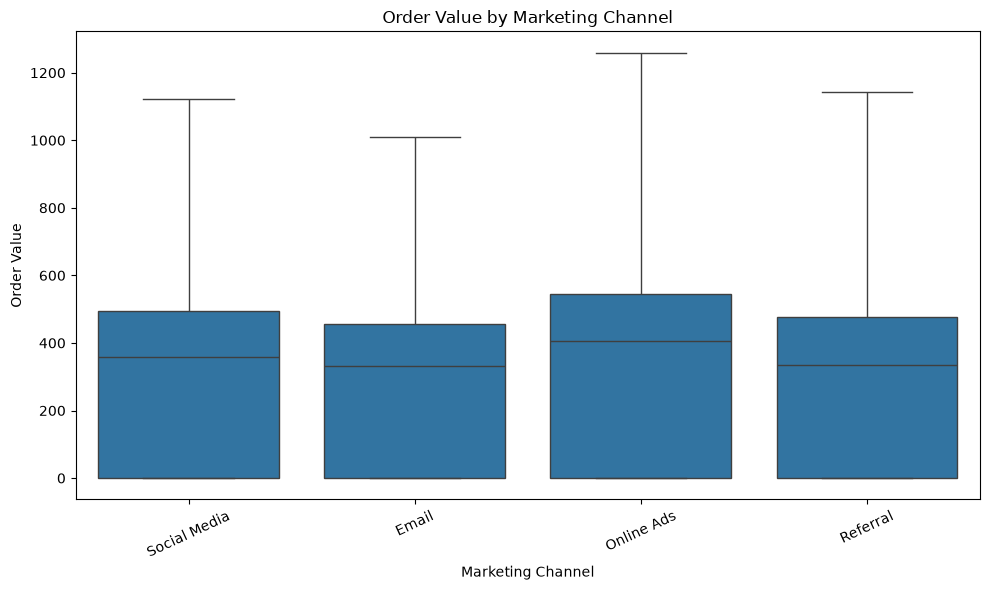

In [63]:
# STEP 58: ANOVA Table + Box Plot
anova_model = ols(
    "Order_Value ~ C(Marketing_Channel)",
    data=anova_data
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)

print(anova_table)

anova_table.to_csv(
    os.path.join(OUT_DIR, "11_anova_marketing_channel.csv")
)

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=anova_data,
    x="Marketing_Channel",
    y="Order_Value"
)
plt.title("Order Value by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Order Value")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "24_anova_boxplot.png"),
    dpi=200
)
plt.show()
plt.close()


In [64]:
# STEP 59: Experimental Design
# Factor 1 = Marketing Channel
# Factor 2 = Discount Level
# Response = Order Value
# Experimental Unit = Individual Order

experimental_df = df_clean.copy()

experimental_df["Discount_Level"] = pd.cut(
    experimental_df["Discount_Percent"],
    bins=[-0.01, 10, 20, 100],
    labels=[
        "Low (0-10%)",
        "Medium (10-20%)",
        "High (20%+)"
    ]
)

print("Factor 1 levels:")
print(experimental_df["Marketing_Channel"].unique())

print("\nFactor 2 levels:")
print(experimental_df["Discount_Level"].unique())

print("\nResponse variable: Order_Value")
print("Experimental unit: Individual Order")

experiment_summary = (
    experimental_df
    .groupby(
        ["Marketing_Channel", "Discount_Level"],
        observed=True
    )["Order_Value"]
    .agg(["count", "mean", "std"])
    .reset_index()
)

print(experiment_summary.round(2))

experiment_summary.to_csv(
    os.path.join(OUT_DIR, "12_experimental_design_summary.csv"),
    index=False
)


Factor 1 levels:
<ArrowStringArray>
['Social Media', 'Email', 'Online Ads', 'Referral']
Length: 4, dtype: str

Factor 2 levels:
['Medium (10-20%)', 'Low (0-10%)', 'High (20%+)']
Categories (3, str): ['Low (0-10%)' < 'Medium (10-20%)' < 'High (20%+)']

Response variable: Order_Value
Experimental unit: Individual Order
   Marketing_Channel   Discount_Level  count    mean     std
0              Email      Low (0-10%)    470  331.22  265.82
1              Email  Medium (10-20%)   1056  295.50  239.83
2              Email      High (20%+)    269  275.31  227.75
3         Online Ads      Low (0-10%)    815  374.97  308.35
4         Online Ads  Medium (10-20%)   1819  358.68  274.92
5         Online Ads      High (20%+)    525  340.40  254.09
6           Referral      Low (0-10%)    399  359.93  264.27
7           Referral  Medium (10-20%)    916  309.36  241.14
8           Referral      High (20%+)    288  274.02  219.87
9       Social Media      Low (0-10%)    891  344.20  286.54
10      So

In [65]:
# STEP 60: Factorial Experiment – Two-Factor ANOVA
factor_model = ols(
    "Order_Value ~ C(Marketing_Channel) * C(Discount_Level)",
    data=experimental_df.dropna()
).fit()

factorial_anova = sm.stats.anova_lm(
    factor_model,
    typ=2
)

print(factorial_anova)

factorial_anova.to_csv(
    os.path.join(OUT_DIR, "13_factorial_anova.csv")
)


                                              sum_sq      df          F  \
C(Marketing_Channel)                    5.004388e+06     3.0  24.226472   
C(Discount_Level)                       3.160686e+06     2.0  22.951542   
C(Marketing_Channel):C(Discount_Level)  3.663131e+05     6.0   0.886669   
Residual                                6.877302e+08  9988.0        NaN   

                                              PR(>F)  
C(Marketing_Channel)                    1.294103e-15  
C(Discount_Level)                       1.135290e-10  
C(Marketing_Channel):C(Discount_Level)  5.035149e-01  
Residual                                         NaN  


Discount_Level     Low (0-10%)  Medium (10-20%)  High (20%+)
Marketing_Channel                                           
Email                   331.22           295.50       275.31
Online Ads              374.97           358.68       340.40
Referral                359.93           309.36       274.02
Social Media            344.20           316.66       286.13


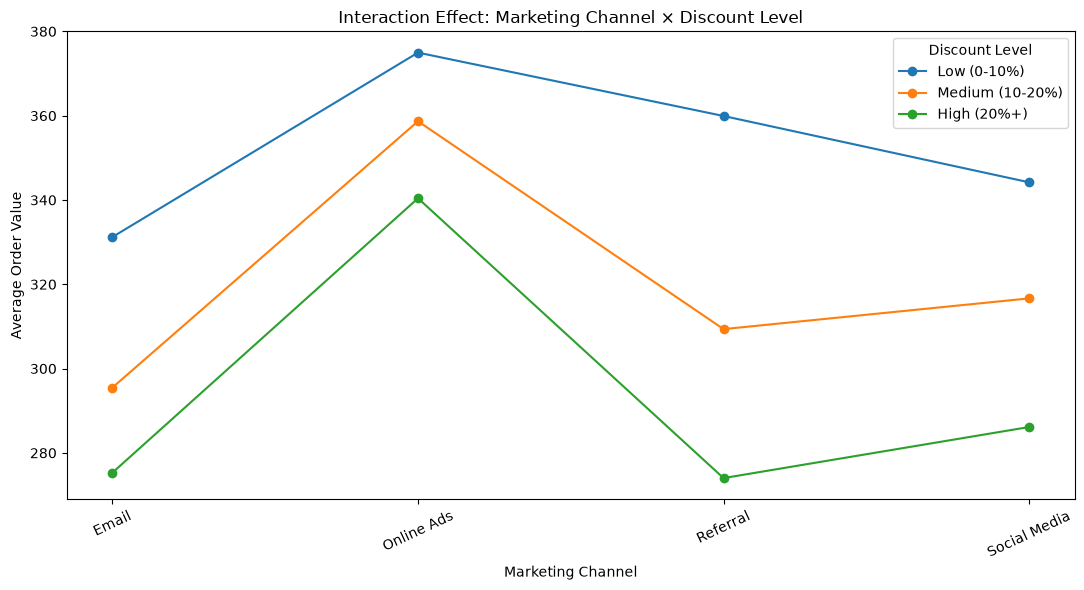

In [66]:
# STEP 61: Factorial Interaction Plot
interaction_means = (
    experimental_df
    .groupby(
        ["Marketing_Channel", "Discount_Level"],
        observed=True
    )["Order_Value"]
    .mean()
    .unstack()
)

print(interaction_means.round(2))

plt.figure(figsize=(11, 6))

for discount_level in interaction_means.columns:
    plt.plot(
        interaction_means.index,
        interaction_means[discount_level],
        marker="o",
        label=str(discount_level)
    )

plt.title("Interaction Effect: Marketing Channel × Discount Level")
plt.xlabel("Marketing Channel")
plt.ylabel("Average Order Value")
plt.legend(title="Discount Level")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(
    os.path.join(OUT_DIR, "25_factorial_interaction.png"),
    dpi=200
)
plt.show()
plt.close()


In [67]:
# STEP 62: Final KPI Summary
kpis = {
    "Total Order Value": df_clean["Order_Value"].sum(),
    "Total Profit": df_clean["Profit"].sum(),
    "Total Orders": len(df_clean),
    "Completed Orders": df_clean["Order_Status"].eq("Completed").sum(),
    "Average Order Value": df_clean["Order_Value"].mean(),
    "Average Delivery Time": df_clean["Delivery_Time_min"].mean(),
    "Average Customer Rating": df_clean["Customer_Rating"].mean(),
    "Conversion Rate (%)": df_clean["Conversion_Status"].eq("Converted").mean() * 100,
    "Refund Rate (%)": df_clean["Returned_Refund"].mean() * 100
}

kpi_df = pd.DataFrame(
    list(kpis.items()),
    columns=["KPI", "Value"]
)

print(kpi_df.round(2))

kpi_df.to_csv(
    os.path.join(OUT_DIR, "14_kpi_summary.csv"),
    index=False
)


                       KPI       Value
0        Total Order Value  3282040.87
1             Total Profit   710647.76
2             Total Orders    10000.00
3         Completed Orders     6845.00
4      Average Order Value      328.20
5    Average Delivery Time       31.65
6  Average Customer Rating        4.64
7      Conversion Rate (%)       74.61
8          Refund Rate (%)        2.50


In [68]:
# STEP 63: Dashboard-ready dataset
dashboard_df = df_clean.copy()

dashboard_df["Month"] = (
    dashboard_df["Order_Date"]
    .dt.to_period("M")
    .astype(str)
)

dashboard_df.to_csv(
    os.path.join(OUT_DIR, "15_dashboard_ready_data.csv"),
    index=False
)

print("Dashboard-ready data saved.")


Dashboard-ready data saved.


In [69]:
# STEP 64: List all generated output files
for file_name in sorted(os.listdir(OUT_DIR)):
    print(file_name)


01_bar_order_value_by_category.png
01_descriptive_statistics.csv
02_bar_profit_by_channel.png
02_correlation_matrix.csv
03_histogram_order_value.png
04_histogram_delivery_time.png
05_boxplot_order_value_category.png
06_pie_payment_method.png
07_forecast_accuracy.csv
07_scatter_distance_vs_time.png
08_future_forecast.csv
08_sales_by_city.png
09_distribution_order_value_histogram.png
09_optimization_results.csv
10_distribution_order_value_boxplot.png
10_simulation_results.csv
11_anova_marketing_channel.csv
11_correlation_heatmap.png
12_experimental_design_summary.csv
12_regression_marketing_spend_order_value.png
13_factorial_anova.csv
13_normal_distribution.png
14_kpi_summary.csv
14_uniform_distribution.png
15_dashboard_ready_data.csv
15_exponential_distribution.png
16_decision_tree.png
17_sampling_distribution_n30.png
18_bootstrap_distribution.png
19_ab_test_conversion_rates.png
20_monthly_sales_time_series.png
21_seasonality_pattern.png
22_forecast_comparison.png
23_simulation_shortage